# 🌍 Renewable Energy Adoption Predictor
### End-to-End Machine Learning Pipeline | Logistic Regression
---
> **Dataset:** Renewable Energy Adoption Dataset (Kaggle — Tarunesh Burman)  
> **Objective:** Classify whether a country/region has adopted renewable energy based on socio-economic and environmental features  
> **Model:** Logistic Regression with advanced feature engineering and hyperparameter optimization

## 📦 1. Library Imports

In [11]:
!pip install imbalanced-learn statsmodels plotly -q

In [12]:
from google.colab import drive
import os
os.chdir('/content')
print(os.listdir('/content'))

['.config', 'Renewable_Energy_Adoption.csv', 'sample_data']


In [13]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Statistical Analysis ─────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, normaltest

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PowerTransformer
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, RFE, mutual_info_classif
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    balanced_accuracy_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

# ─── Imbalanced Learning ──────────────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("⚠️  imbalanced-learn not found. Run: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

# ─── Model Persistence ────────────────────────────────────────────────────────
import joblib
import pickle
import os
import json
import time
from datetime import datetime

# ─── Display Configuration ────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.width', 120)

# ─── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0D1117',
    'axes.facecolor':    '#161B22',
    'axes.edgecolor':    '#30363D',
    'axes.labelcolor':   '#E6EDF3',
    'axes.titlecolor':   '#E6EDF3',
    'xtick.color':       '#8B949E',
    'ytick.color':       '#8B949E',
    'grid.color':        '#21262D',
    'grid.linewidth':    0.8,
    'text.color':        '#E6EDF3',
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'figure.titlesize':  16,
})

PALETTE = {
    'primary':   '#58A6FF',
    'success':   '#3FB950',
    'warning':   '#D29922',
    'danger':    '#F85149',
    'purple':    '#BC8CFF',
    'teal':      '#39D353',
    'orange':    '#FFA657',
}
CMAP = sns.diverging_palette(220, 20, as_cmap=True)

print('✅ All libraries loaded successfully!')
print(f'📅 Run timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ All libraries loaded successfully!
📅 Run timestamp: 2026-03-20 15:18:13


## 📂 2. Load Dataset

In [14]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# Update path as needed after downloading from Kaggle
DATA_PATH = '/content/Renewable_Energy_Adoption.csv'   # <── change if different filename

df = pd.read_csv(DATA_PATH)
df_raw = df.copy()   # keep pristine backup

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📦 Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('\n📋 First 5 rows:')
df.head()

✅ Dataset loaded: 1,000 rows × 11 columns
📦 Memory usage : 0.26 MB

📋 First 5 rows:


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Region,Adoption_Status
0,4.9902,7.1987,16293.4926,0.4154,1841.8373,84.1122,76276.8559,High,Moderate,Urban,High
1,4.1768,5.8554,17723.2482,0.4694,1989.5593,36.8935,46921.1477,Medium,Easy,Suburban,Medium
2,5.5216,4.2913,2276.2640,0.2902,375.5433,80.4408,78001.6594,Low,Easy,Suburban,Medium
3,4.9545,11.2026,17326.7601,0.4155,327.1382,74.0252,95933.4760,High,Moderate,Urban,Medium
4,5.4086,3.4381,15993.8749,0.2484,1406.0145,65.6385,82241.4806,High,Moderate,Suburban,Low


In [15]:
print('📐 Shape:', df.shape)
print('\n📊 Column names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

📐 Shape: (1000, 11)

📊 Column names:
   1. Solar_Exposure
   2. Wind_Speed
   3. Government_Subsidy
   4. Electricity_Price
   5. Population_Density
   6. Urbanization_Rate
   7. Household_Income
   8. Awareness_Programs
   9. Grid_Accessibility
  10. Region
  11. Adoption_Status


## 🔍 3. Data Exploration

In [16]:
# ─── Data Types & Basic Info ───────────────────────────────────────────────────
print('=' * 65)
print('                    DATASET OVERVIEW')
print('=' * 65)
print(f"  Rows               : {df.shape[0]:,}")
print(f"  Columns            : {df.shape[1]}")
print(f"  Numeric columns    : {df.select_dtypes(include='number').shape[1]}")
print(f"  Categorical columns: {df.select_dtypes(include='object').shape[1]}")
print(f"  Duplicate rows     : {df.duplicated().sum():,}")
print(f"  Total missing vals : {df.isnull().sum().sum():,}")
print('=' * 65)

                    DATASET OVERVIEW
  Rows               : 1,000
  Columns            : 11
  Numeric columns    : 7
  Categorical columns: 4
  Duplicate rows     : 0
  Total missing vals : 0


In [17]:
# ─── Detailed Column Info ─────────────────────────────────────────────────────
info_df = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notnull().sum(),
    'null_count':   df.isnull().sum(),
    'null_pct':     (df.isnull().sum() / len(df) * 100).round(2),
    'unique':       df.nunique(),
    'sample_val':   df.iloc[0]
})
print('\n📋 Column-level Information:')
display(info_df)


📋 Column-level Information:


,dtype,non_null,null_count,null_pct,unique,sample_val
Solar_Exposure,float64,1000,0,0.0000,1000,4.9902
Wind_Speed,float64,1000,0,0.0000,1000,7.1987
Government_Subsidy,float64,1000,0,0.0000,1000,16293.4926
Electricity_Price,float64,1000,0,0.0000,1000,0.4154
Population_Density,float64,1000,0,0.0000,1000,1841.8373
Urbanization_Rate,float64,1000,0,0.0000,1000,84.1122
Household_Income,float64,1000,0,0.0000,1000,76276.8559
Awareness_Programs,object,1000,0,0.0000,3,High
Grid_Accessibility,object,1000,0,0.0000,3,Moderate
Region,object,1000,0,0.0000,3,Urban


In [18]:
# ─── Statistical Summary ──────────────────────────────────────────────────────
print('📈 Descriptive Statistics — Numeric Features:')
display(df.describe(include='number').T.style
    .background_gradient(cmap='YlOrRd', axis=1)
    .format('{:.3f}'))

print('\n🔤 Descriptive Statistics — Categorical Features:')
display(df.describe(include='object'))

📈 Descriptive Statistics — Numeric Features:


,count,mean,std,min,25%,50%,75%,max
Solar_Exposure,1000.000,3.974,1.159,2.001,3.004,3.977,4.955,5.996
Wind_Speed,1000.000,7.494,2.573,3.011,5.313,7.380,9.698,11.979
Government_Subsidy,1000.000,10403.973,5395.021,1001.020,5769.525,10567.674,14820.706,19973.468
Electricity_Price,1000.000,0.306,0.116,0.100,0.205,0.311,0.409,0.500
Population_Density,1000.000,1027.512,564.965,55.035,533.686,1050.011,1497.503,1997.827
Urbanization_Rate,1000.000,60.151,17.506,30.029,45.251,60.743,74.967,89.877
Household_Income,1000.000,60014.586,23047.242,20062.714,40294.457,60369.093,79698.724,99898.332



🔤 Descriptive Statistics — Categorical Features:


,Awareness_Programs,Grid_Accessibility,Region,Adoption_Status
count,1000,1000,1000,1000
unique,3,3,3,3
top,Low,Easy,Rural,Low
freq,347,346,374,365


In [19]:
# ─── Identify Target Column Automatically ─────────────────────────────────────
# Prioritise columns with 'adopt' in name; fall back to binary numerics
adoption_candidates = [c for c in df.columns if 'adopt' in c.lower()]
if not adoption_candidates:
    adoption_candidates = [
        c for c in df.select_dtypes(include='number').columns
        if df[c].nunique() == 2 and set(df[c].dropna().unique()).issubset({0, 1})
    ]

TARGET = adoption_candidates[0] if adoption_candidates else df.columns[-1]
print(f'🎯 Target column identified: "{TARGET}"')
print(f'   Class distribution:\n{df[TARGET].value_counts()}\n')
print(f'   Imbalance ratio: {df[TARGET].value_counts(normalize=True).to_dict()}')

🎯 Target column identified: "Adoption_Status"
   Class distribution:
Adoption_Status
Low       365
High      318
Medium    317
Name: count, dtype: int64

   Imbalance ratio: {'Low': 0.365, 'High': 0.318, 'Medium': 0.317}


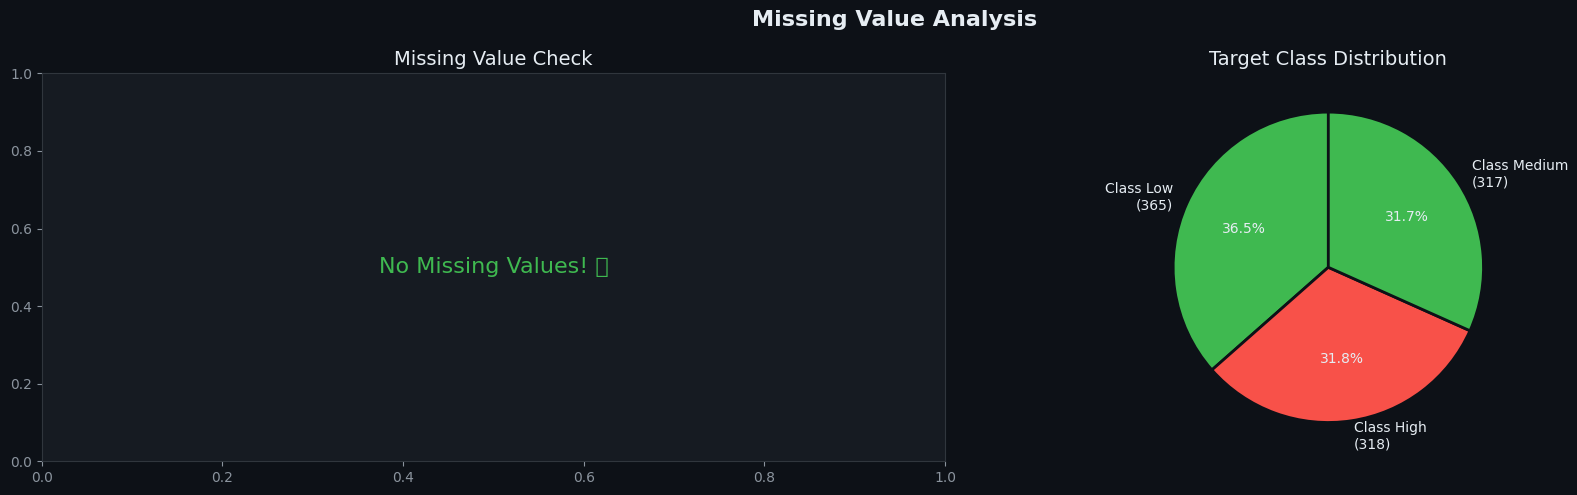

In [20]:
# ─── Missing Value Heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Missing Value Analysis', fontsize=16, fontweight='bold', color='#E6EDF3')

# Heatmap
missing_pct = df.isnull().mean() * 100
missing_df  = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_df) > 0:
    axes[0].barh(missing_df.index, missing_df.values,
                 color=[PALETTE['danger'] if v > 20 else PALETTE['warning']
                        for v in missing_df.values])
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Columns with Missing Data')
    axes[0].axvline(5,  color='#8B949E', linestyle='--', linewidth=0.8, label='5% threshold')
    axes[0].axvline(20, color=PALETTE['danger'], linestyle='--', linewidth=0.8, label='20% threshold')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No Missing Values! ✅',
                 ha='center', va='center', fontsize=16, color=PALETTE['success'],
                 transform=axes[0].transAxes)
    axes[0].set_title('Missing Value Check')

# Class distribution
class_counts = df[TARGET].value_counts()
colors = [PALETTE['success'], PALETTE['danger']]
axes[1].pie(class_counts, labels=[f'Class {i}\n({v:,})' for i, v in class_counts.items()],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': '#0D1117', 'linewidth': 2})
axes[1].set_title('Target Class Distribution')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧹 4. Data Cleaning

In [21]:
# ─── Step 1: Drop Duplicates ──────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f'🗑  Duplicates removed: {before - len(df):,} rows | Remaining: {len(df):,}')

# ─── Step 2: Drop columns with >50% missing ───────────────────────────────────
high_null_cols = df.columns[df.isnull().mean() > 0.5].tolist()
if high_null_cols:
    df.drop(columns=high_null_cols, inplace=True)
    print(f'🗑  Dropped high-null columns: {high_null_cols}')
else:
    print('✅ No columns dropped for high nulls')

# ─── Step 3: Fix data types ───────────────────────────────────────────────────
# Convert numeric-like strings to float
for col in df.select_dtypes(include='object').columns:
    if col == TARGET:
        continue
    try:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    except Exception:
        pass

# ─── Step 4: Encode target if string ──────────────────────────────────────────
if df[TARGET].dtype == object:
    le = LabelEncoder()
    df[TARGET] = le.fit_transform(df[TARGET])
    print(f'🏷  Target label encoded. Classes: {le.classes_}')
else:
    # Ensure 0/1 binary
    if df[TARGET].nunique() > 2:
        median_val = df[TARGET].median()
        df[TARGET] = (df[TARGET] >= median_val).astype(int)
        print(f'⚠️  Target binarised at median ({median_val:.4f})')

# ─── Step 5: Remove constant/near-constant features ───────────────────────────
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
if const_cols:
    df.drop(columns=const_cols, inplace=True)
    print(f'🗑  Removed constant columns: {const_cols}')

# ─── Step 6: Cap extreme outliers (IQR method for numeric) ────────────────────
num_cols = df.select_dtypes(include='number').columns.drop(TARGET, errors='ignore')
outlier_report = {}
for col in num_cols:
    Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 3.0 * IQR
    upper   = Q3 + 3.0 * IQR
    before  = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    if before > 0:
        outlier_report[col] = before

print(f'\n📊 Outlier capping summary (3×IQR rule):')
for col, cnt in outlier_report.items():
    print(f'   {col:35s}: {cnt:5d} values capped')

print(f'\n✅ Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

🗑  Duplicates removed: 0 rows | Remaining: 1,000
✅ No columns dropped for high nulls
🏷  Target label encoded. Classes: ['High' 'Low' 'Medium']

📊 Outlier capping summary (3×IQR rule):

✅ Cleaned dataset: 1,000 rows × 11 columns


In [22]:
# ─── Impute remaining missing values ──────────────────────────────────────────
num_cols  = df.select_dtypes(include='number').columns.drop(TARGET, errors='ignore').tolist()
cat_cols  = df.select_dtypes(include='object').columns.tolist()

if df[num_cols].isnull().sum().sum() > 0:
    knn_imp = KNNImputer(n_neighbors=5)
    df[num_cols] = knn_imp.fit_transform(df[num_cols])
    print('🔧 KNN imputation applied to numeric columns')

if cat_cols and df[cat_cols].isnull().sum().sum() > 0:
    cat_imp = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imp.fit_transform(df[cat_cols])
    print('🔧 Mode imputation applied to categorical columns')

assert df.isnull().sum().sum() == 0, 'Still has nulls!'
print('✅ No missing values remaining')

✅ No missing values remaining


## 📊 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

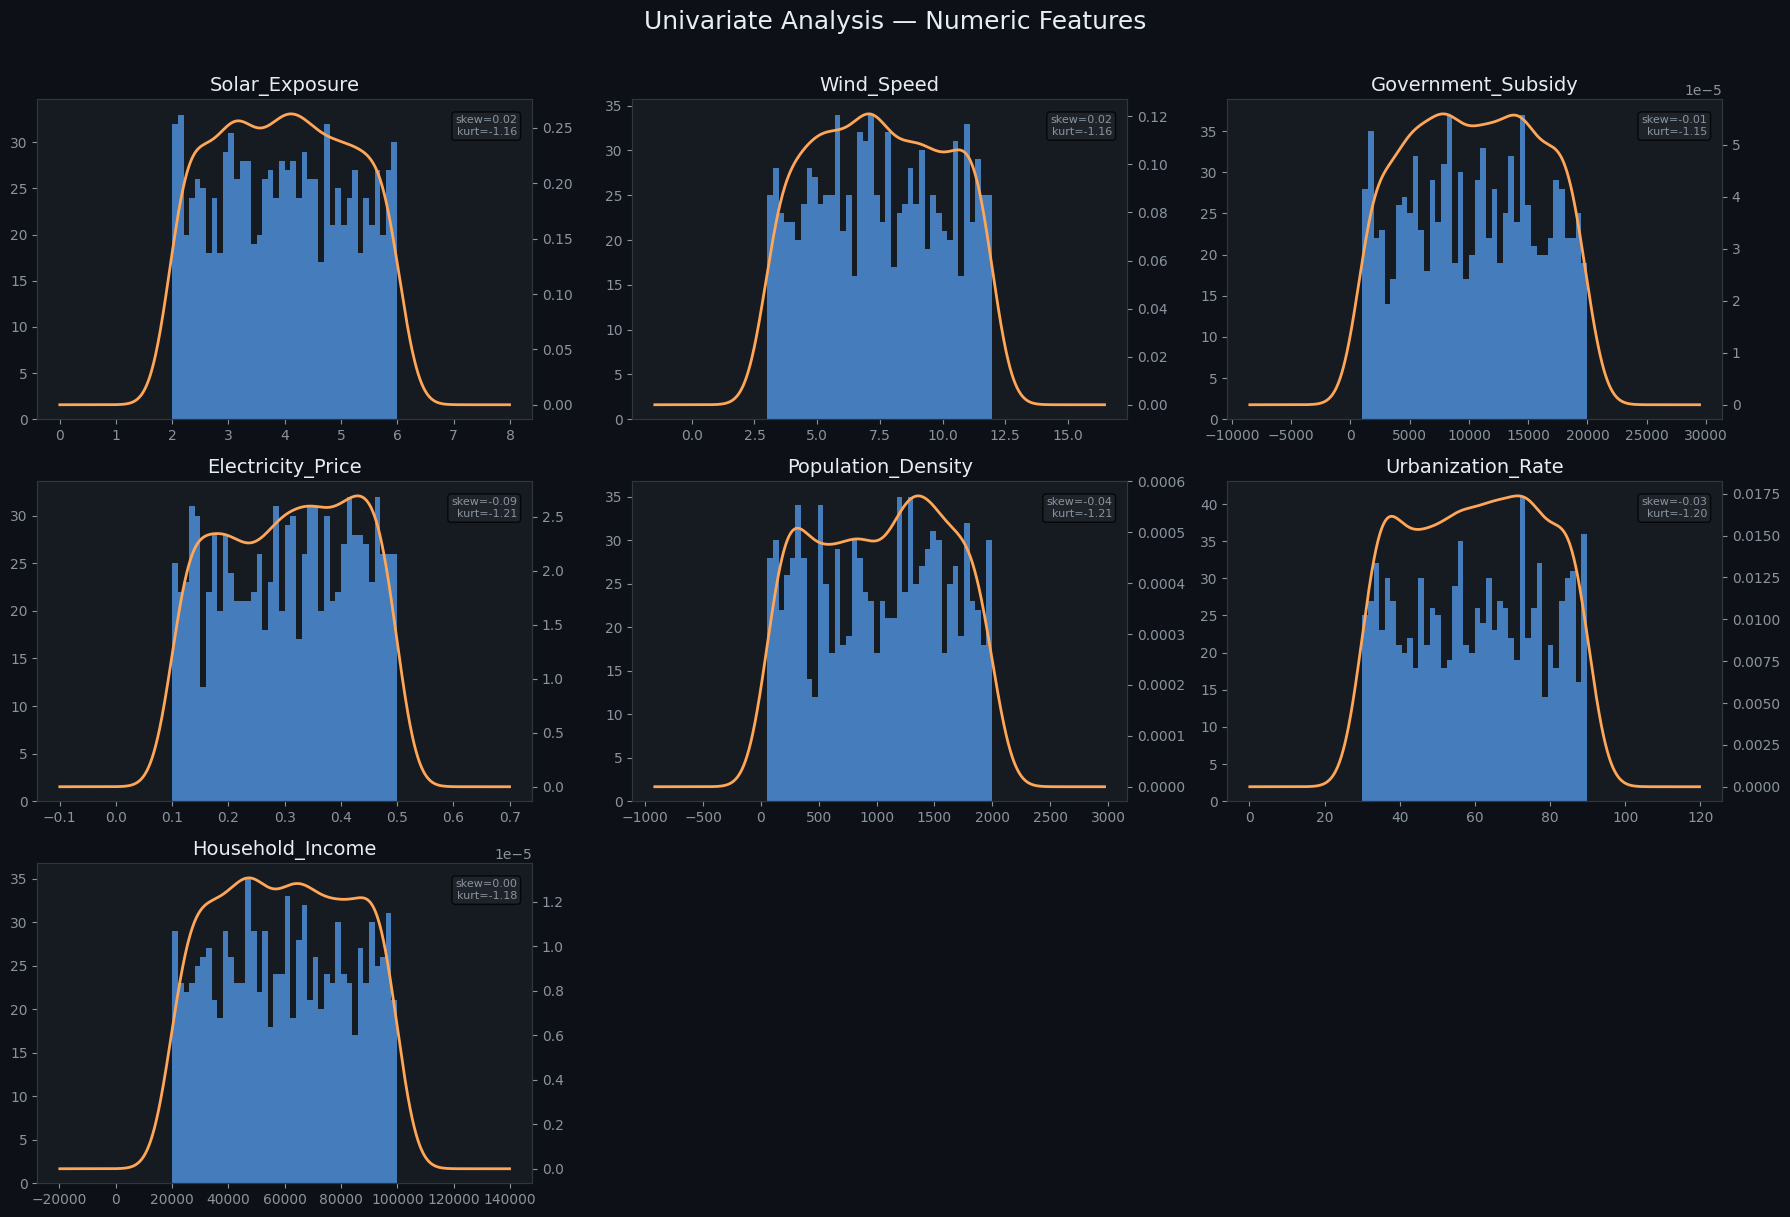

In [23]:
# ─── Numeric Feature Distributions ────────────────────────────────────────────
num_feat = df.select_dtypes(include='number').columns.drop(TARGET, errors='ignore').tolist()
n_cols   = 3
n_rows   = int(np.ceil(len(num_feat) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
fig.suptitle('Univariate Analysis — Numeric Features', fontsize=18, y=1.01)
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(num_feat):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=PALETTE['primary'], alpha=0.7, edgecolor='none')
    ax2 = ax.twinx()
    data.plot.kde(ax=ax2, color=PALETTE['orange'], linewidth=2)
    ax2.set_ylabel('')
    ax2.tick_params(left=False, labelleft=False)
    ax.set_title(col)
    ax.set_xlabel('')
    skew  = data.skew()
    kurt  = data.kurtosis()
    ax.text(0.97, 0.95, f'skew={skew:.2f}\nkurt={kurt:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#8B949E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D', alpha=0.8))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('univariate_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

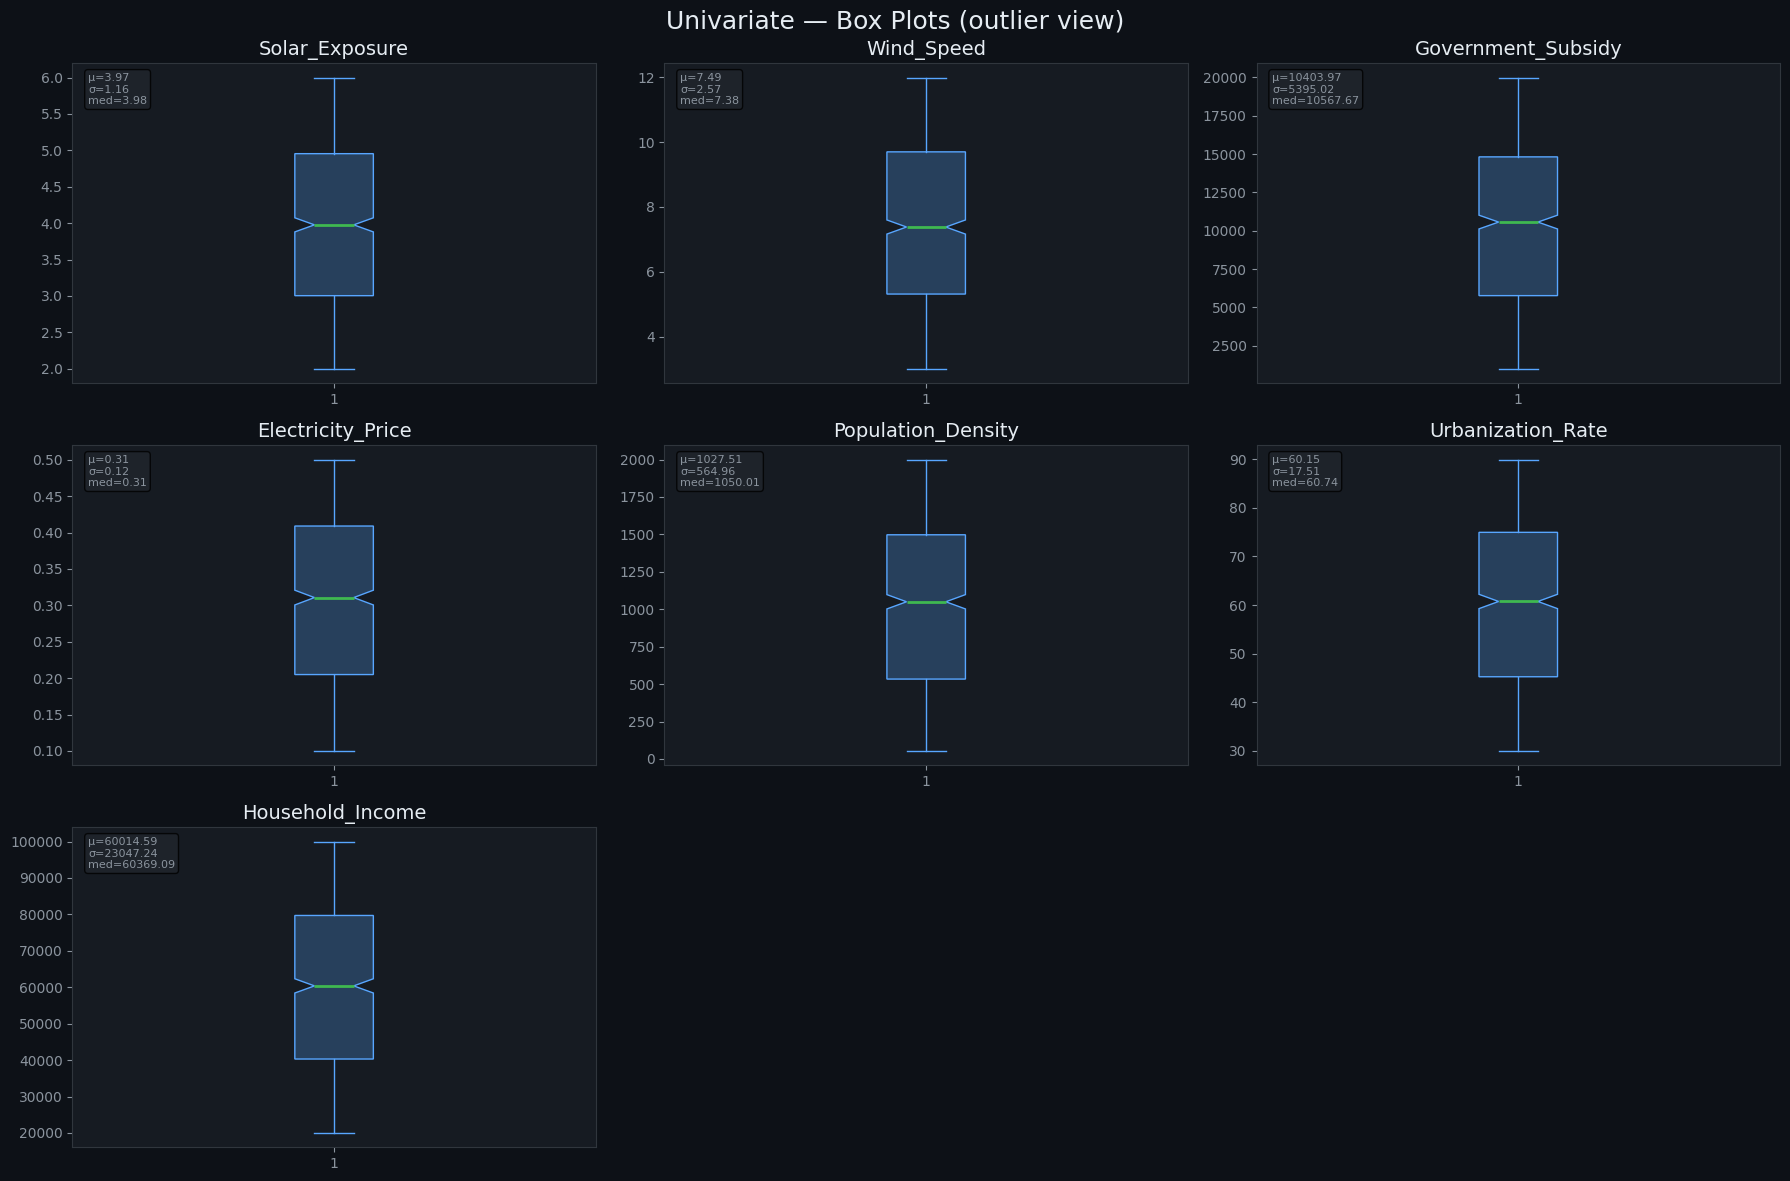

In [24]:
# ─── Box plots — Spread & Outliers ────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
fig.suptitle('Univariate — Box Plots (outlier view)', fontsize=18)
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(num_feat):
    ax = axes[i]
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    notch=True,
                    boxprops=    dict(facecolor=PALETTE['primary']+'44', color=PALETTE['primary']),
                    whiskerprops=dict(color=PALETTE['primary']),
                    capprops=    dict(color=PALETTE['primary']),
                    medianprops= dict(color=PALETTE['success'], linewidth=2),
                    flierprops=  dict(marker='o', color=PALETTE['danger'],
                                      alpha=0.5, markersize=3))
    ax.set_title(col)
    stats_text = (
        f"μ={df[col].mean():.2f}\n"
        f"σ={df[col].std():.2f}\n"
        f"med={df[col].median():.2f}"
    )
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            va='top', fontsize=8, color='#8B949E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D', alpha=0.8))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('univariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

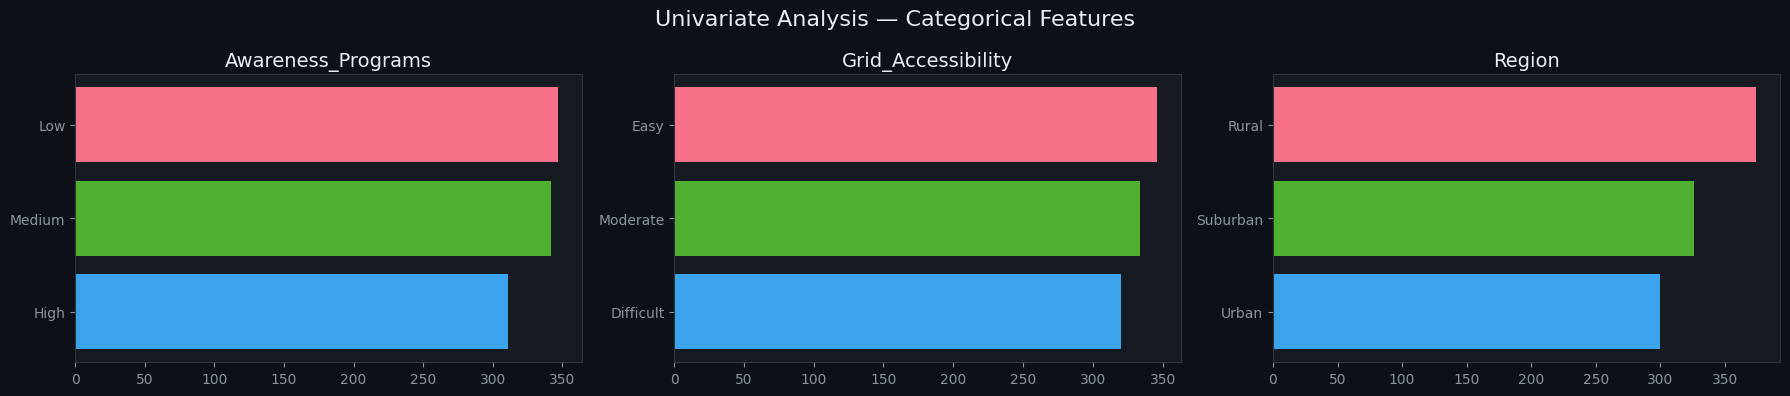

In [25]:
# ─── Categorical Features ─────────────────────────────────────────────────────
cat_feat = df.select_dtypes(include='object').columns.tolist()
if cat_feat:
    n_c  = min(3, len(cat_feat))
    n_r  = int(np.ceil(len(cat_feat) / n_c))
    fig, axes = plt.subplots(n_r, n_c, figsize=(6 * n_c, 4 * n_r))
    fig.suptitle('Univariate Analysis — Categorical Features', fontsize=16)
    axes = axes.flatten() if n_r > 1 else ([axes] if n_c == 1 else axes.tolist())

    for i, col in enumerate(cat_feat[:n_c * n_r]):
        vc = df[col].value_counts().head(20)
        palette = sns.color_palette('husl', len(vc))
        axes[i].barh(vc.index.astype(str), vc.values, color=palette)
        axes[i].set_title(col)
        axes[i].invert_yaxis()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('univariate_categorical.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No categorical features to plot.')

### 5.2 Bivariate Analysis

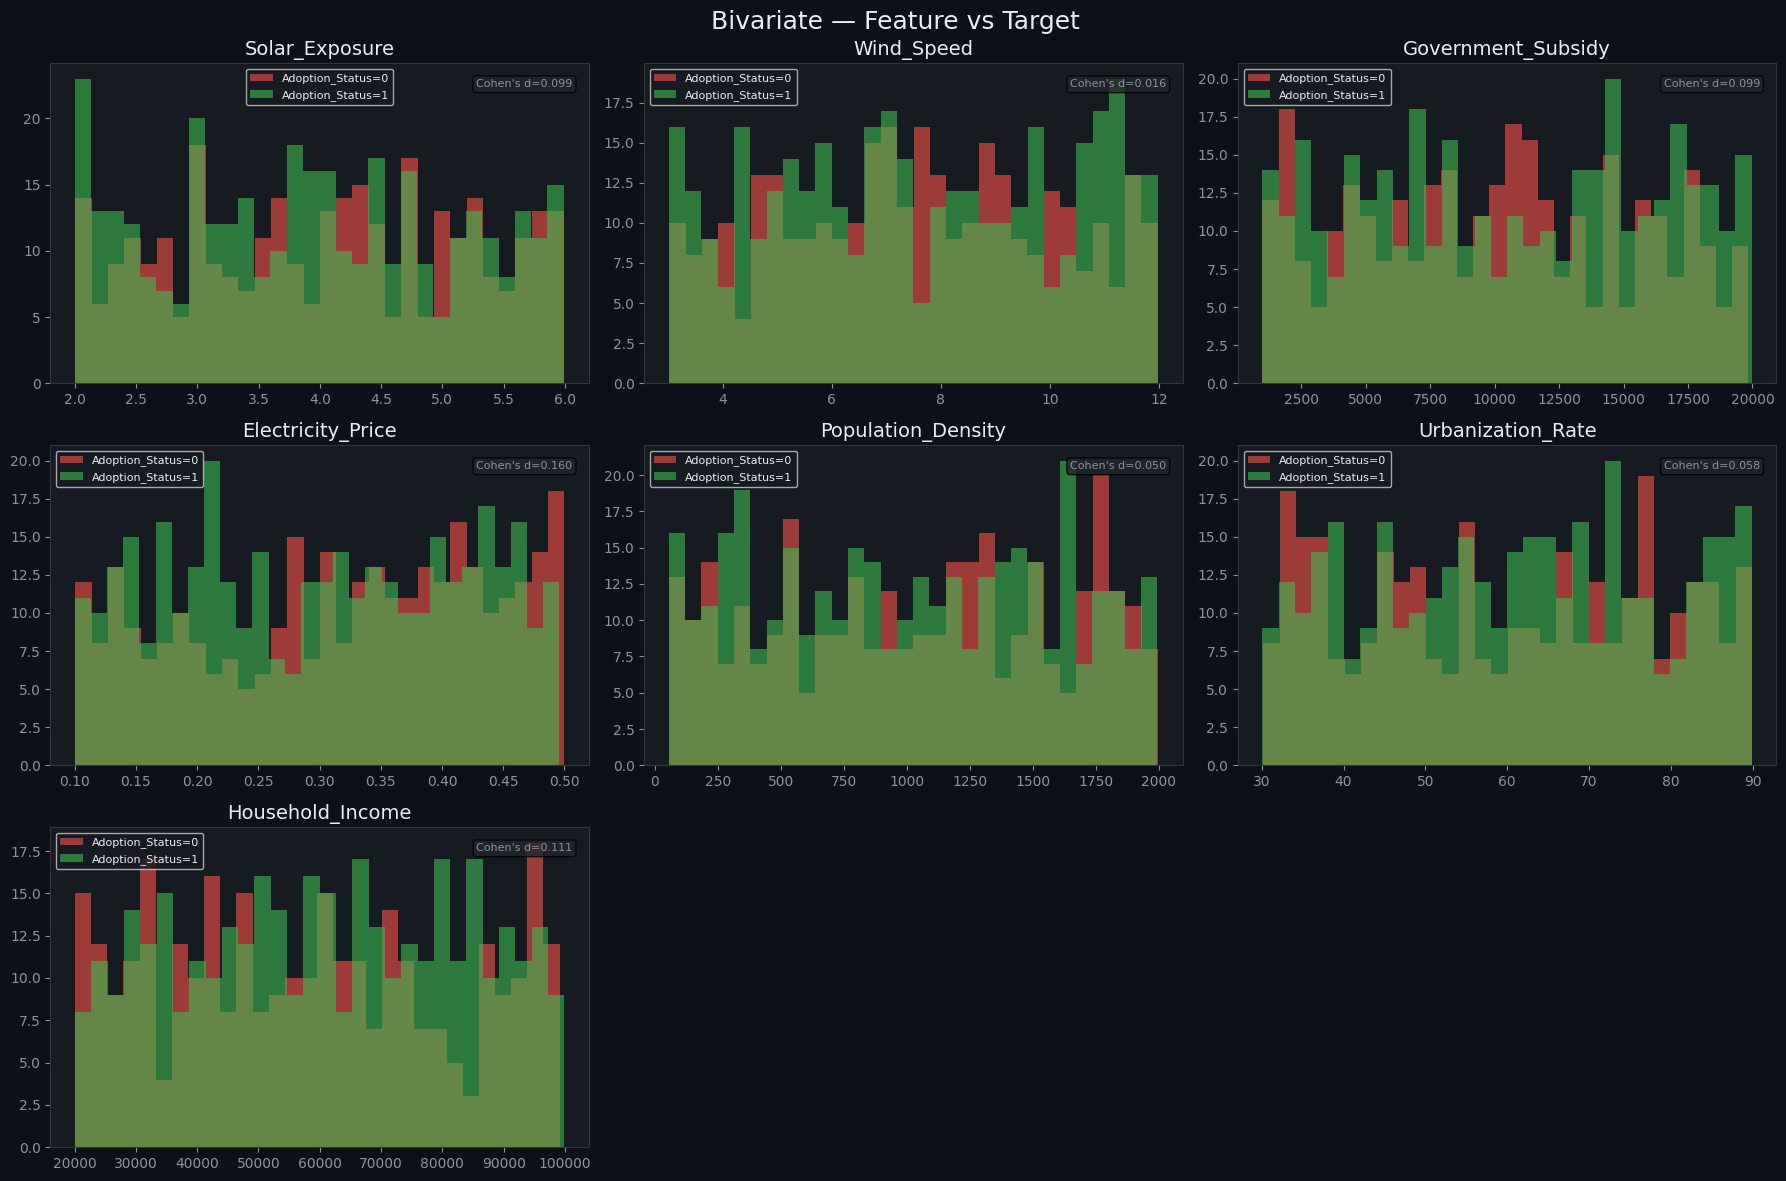

In [26]:
# ─── Feature vs Target ────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
fig.suptitle('Bivariate — Feature vs Target', fontsize=18)
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(num_feat):
    ax = axes[i]
    for cls, clr in zip([0, 1], [PALETTE['danger'], PALETTE['success']]):
        subset = df[df[TARGET] == cls][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=clr,
                label=f'{TARGET}={cls}', edgecolor='none')
    ax.set_title(col)
    ax.legend(fontsize=8)

    # Effect size (Cohen's d)
    g0 = df[df[TARGET] == 0][col].dropna()
    g1 = df[df[TARGET] == 1][col].dropna()
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    d = abs(g1.mean() - g0.mean()) / (pooled_std + 1e-9)
    ax.text(0.97, 0.95, f"Cohen's d={d:.3f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#8B949E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D', alpha=0.8))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('bivariate_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ─── Correlation with Target (point-biserial) ──────────────────────────────────
corr_target = {}
for col in num_feat:
    r, p = pointbiserialr(df[col].fillna(0), df[TARGET])
    corr_target[col] = {'correlation': r, 'p_value': p, 'significant': p < 0.05}

corr_df = pd.DataFrame(corr_target).T.sort_values('correlation', key=abs, ascending=False)
print('📈 Point-Biserial Correlation with Target:')
display(corr_df.style
    .background_gradient(subset=['correlation'], cmap='RdYlGn', vmin=-1, vmax=1)
    .format({'correlation': '{:.4f}', 'p_value': '{:.4e}'}))

📈 Point-Biserial Correlation with Target:


,correlation,p_value,significant
Electricity_Price,-0.0696,2.7676e-02,True
Household_Income,0.0429,1.7514e-01,False
Solar_Exposure,-0.0370,2.4256e-01,False
Wind_Speed,-0.0338,2.8521e-01,False
Government_Subsidy,0.0286,3.6559e-01,False
Population_Density,-0.0028,9.2909e-01,False
Urbanization_Rate,-0.0022,9.4512e-01,False


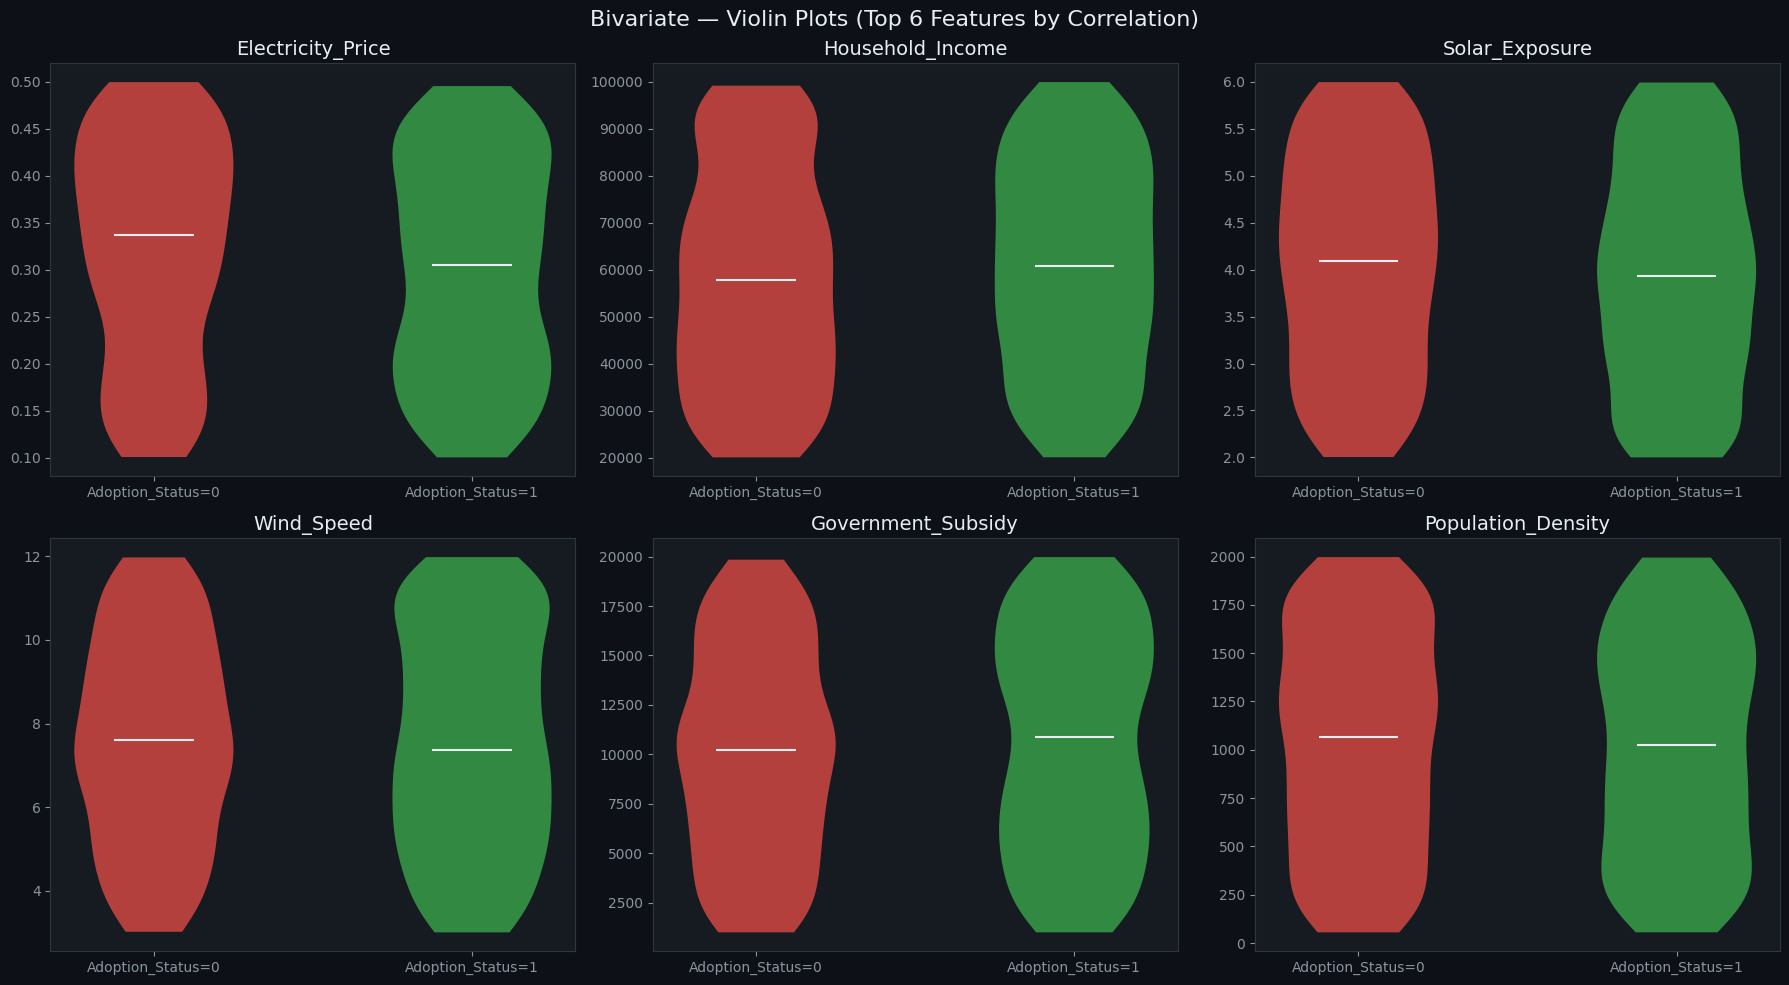

In [28]:
# ─── Violin + Box Plot by Target ──────────────────────────────────────────────
top_features = corr_df.head(min(6, len(corr_df))).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bivariate — Violin Plots (Top 6 Features by Correlation)', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    data_0 = df[df[TARGET] == 0][col].dropna()
    data_1 = df[df[TARGET] == 1][col].dropna()

    vp = ax.violinplot([data_0, data_1], positions=[0, 1],
                       showmedians=True, showextrema=False)
    for j, body in enumerate(vp['bodies']):
        body.set_facecolor([PALETTE['danger'], PALETTE['success']][j])
        body.set_alpha(0.7)
    vp['cmedians'].set_color('#E6EDF3')

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{TARGET}=0', f'{TARGET}=1'])
    ax.set_title(col)

for j in range(len(top_features), 6):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('bivariate_violin.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Multivariate Analysis

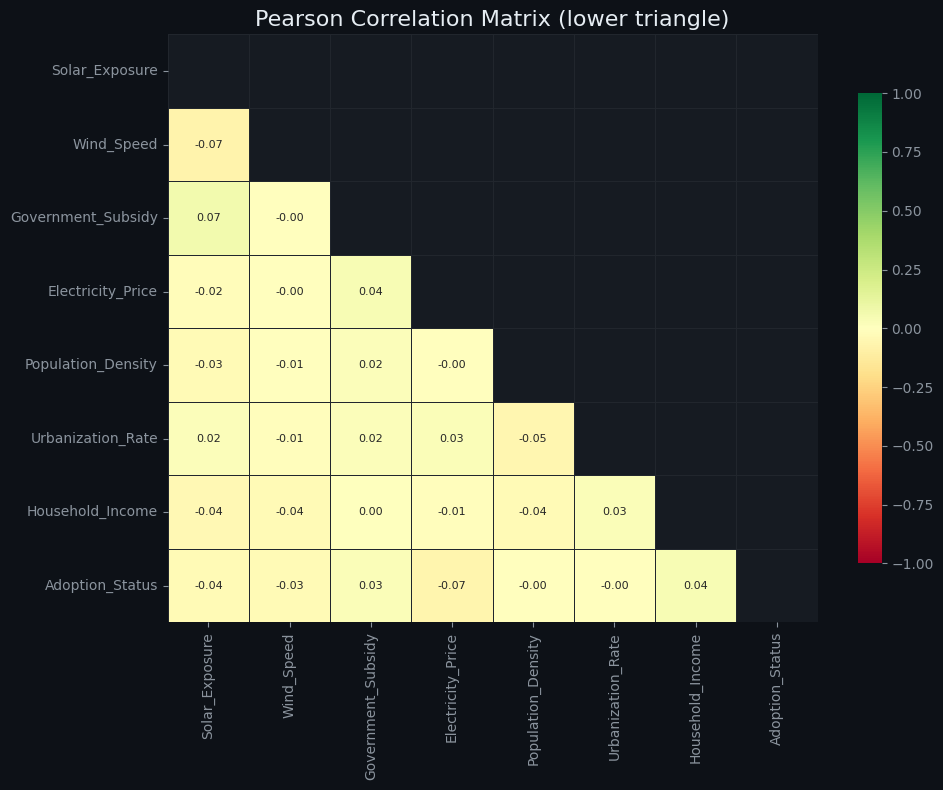

In [29]:
# ─── Correlation Heatmap ──────────────────────────────────────────────────────
corr_matrix = df[num_feat + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(max(10, len(num_feat)), max(8, len(num_feat) - 2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#21262D',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Matrix (lower triangle)', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

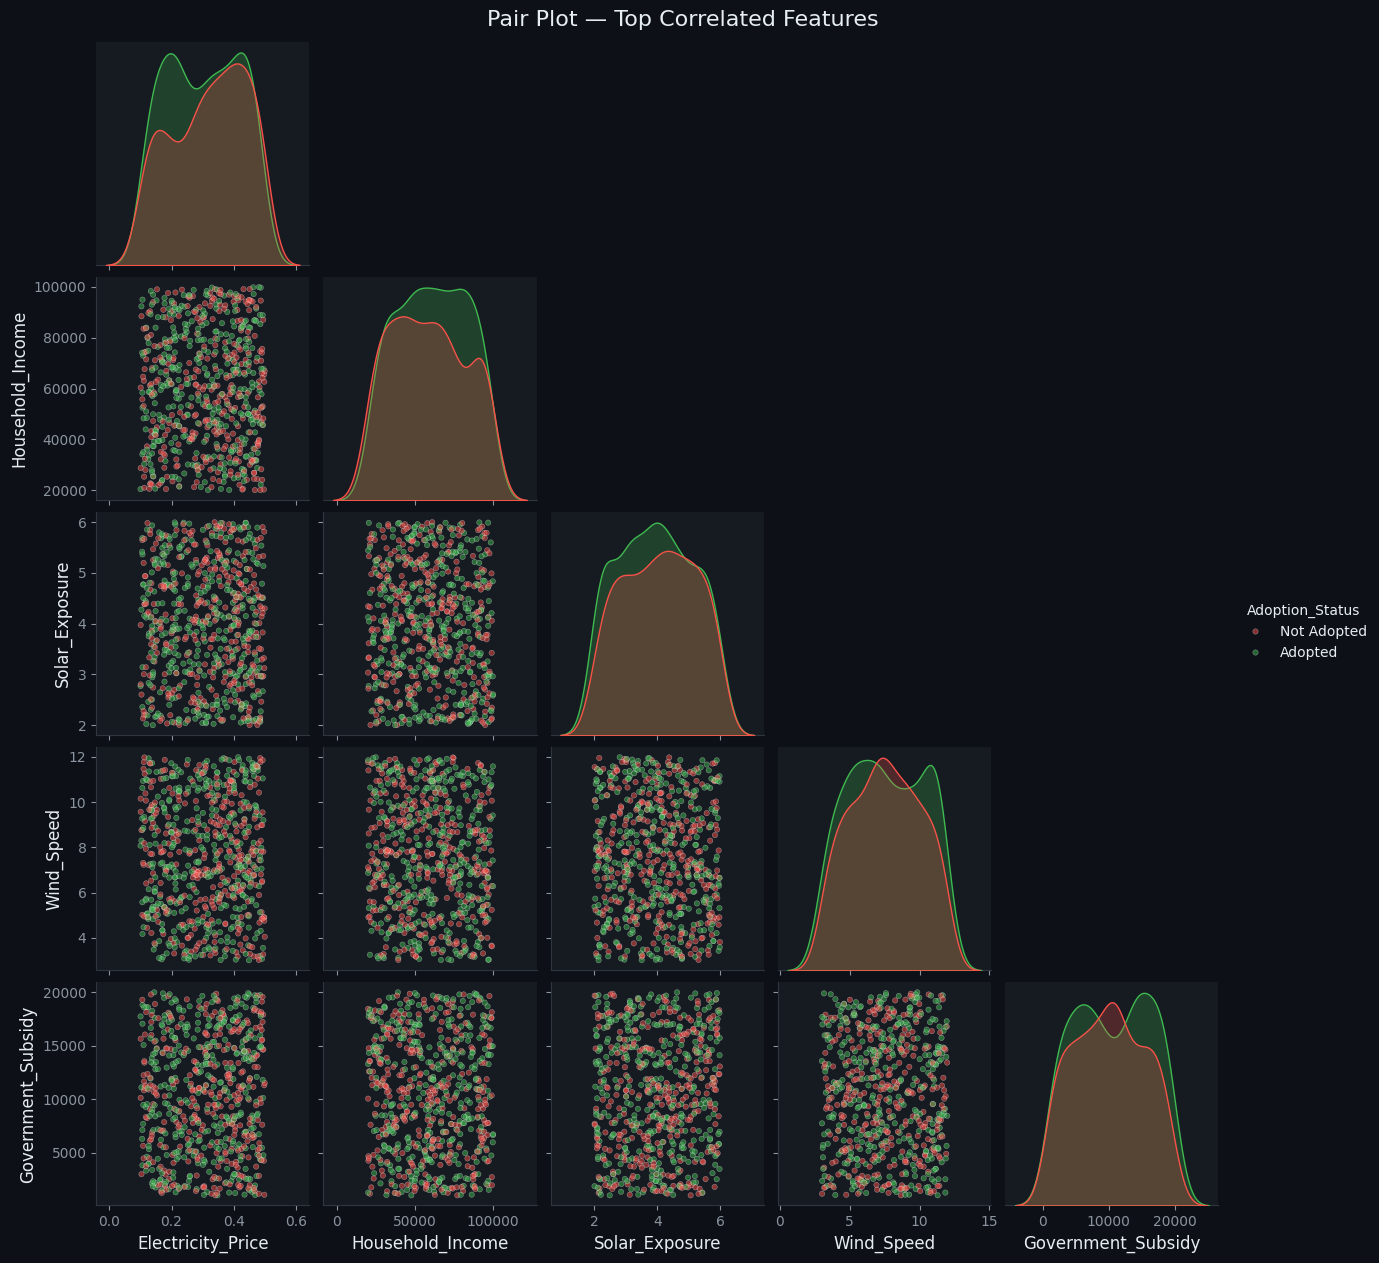

In [30]:
# ─── Pair Plot (top-5 features) ───────────────────────────────────────────────
top5 = corr_df.head(min(5, len(corr_df))).index.tolist()
pair_df = df[top5 + [TARGET]].copy()
pair_df[TARGET] = pair_df[TARGET].map({0: 'Not Adopted', 1: 'Adopted'})

pair_grid = sns.pairplot(
    pair_df, hue=TARGET,
    palette={'Not Adopted': PALETTE['danger'], 'Adopted': PALETTE['success']},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15},
    corner=True
)
pair_grid.fig.suptitle('Pair Plot — Top Correlated Features', y=1.01, fontsize=16)
pair_grid.fig.patch.set_facecolor('#0D1117')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

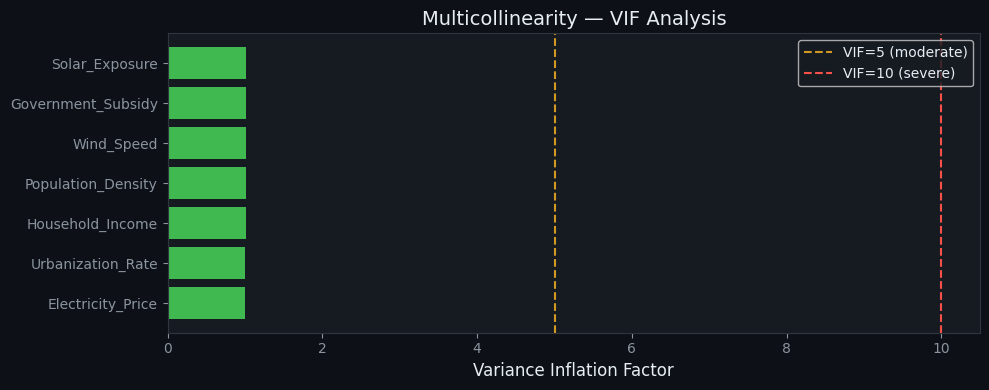

,Feature,VIF
1,Solar_Exposure,1.0146
3,Government_Subsidy,1.0080
2,Wind_Speed,1.0072
5,Population_Density,1.0061
7,Household_Income,1.0056
6,Urbanization_Rate,1.0052
4,Electricity_Price,1.0033


In [31]:
# ─── Multicollinearity — VIF ───────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

vif_df_input = df[num_feat].dropna()
X_vif = add_constant(vif_df_input)
vif_scores = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query('Feature != "const"').sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(vif_scores) * 0.4)))
colors = [PALETTE['danger'] if v > 10 else
          (PALETTE['warning'] if v > 5 else PALETTE['success'])
          for v in vif_scores['VIF']]
ax.barh(vif_scores['Feature'], vif_scores['VIF'], color=colors)
ax.axvline(5,  color=PALETTE['warning'], linestyle='--', label='VIF=5 (moderate)')
ax.axvline(10, color=PALETTE['danger'],  linestyle='--', label='VIF=10 (severe)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity — VIF Analysis')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

display(vif_scores)

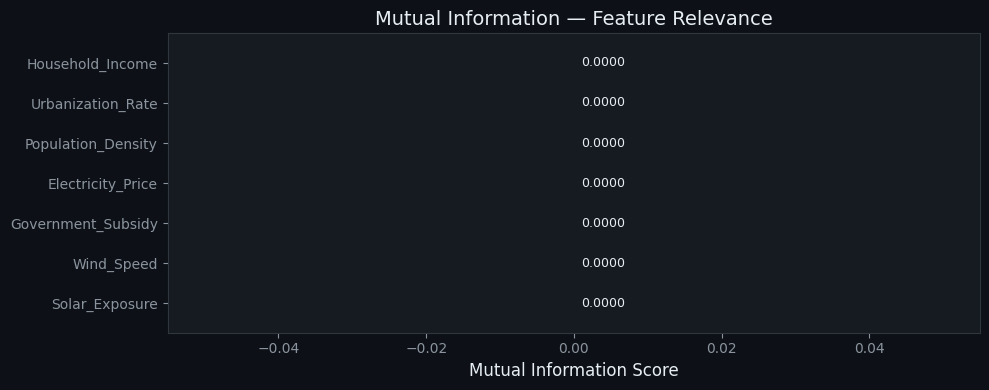

In [32]:
# ─── Mutual Information ───────────────────────────────────────────────────────
mi_scores = mutual_info_classif(df[num_feat].fillna(0), df[TARGET],
                                 random_state=42, n_neighbors=5)
mi_df = pd.Series(mi_scores, index=num_feat).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(mi_df) * 0.35)))
bars = ax.barh(mi_df.index, mi_df.values,
               color=plt.cm.YlOrRd(mi_df.values / mi_df.max()))
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information — Feature Relevance')
for bar, val in zip(bars, mi_df.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9, color='#E6EDF3')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 6. Data Preprocessing

In [33]:
# ─── Feature Engineering ──────────────────────────────────────────────────────
# Add ratio features if relevant columns exist
fe_cols = df.select_dtypes(include='number').columns.drop(TARGET, errors='ignore').tolist()

# Interaction terms for top 3 correlated pairs
for i in range(min(3, len(top5) - 1)):
    c1, c2 = top5[i], top5[i + 1]
    df[f'{c1}_x_{c2}'] = df[c1] * df[c2]
    df[f'{c1}_div_{c2}'] = df[c1] / (df[c2].replace(0, np.nan)).fillna(0)

# Log-transform skewed columns
for col in num_feat:
    if abs(df[col].skew()) > 1.5 and df[col].min() >= 0:
        df[f'log_{col}'] = np.log1p(df[col])

print(f'✅ Feature engineering complete. New shape: {df.shape}')

✅ Feature engineering complete. New shape: (1000, 17)


In [34]:
# ─── Define X & y ─────────────────────────────────────────────────────────────
cat_features = df.select_dtypes(include='object').columns.tolist()
num_features = df.select_dtypes(include='number').columns.drop(TARGET, errors='ignore').tolist()

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {y.value_counts(normalize=True).to_dict()}')

X shape: (1000, 16)
y shape: (1000,)
Class balance: {1: 0.365, 0: 0.318, 2: 0.317}


In [35]:
# ─── Train / Validation / Test Split (60/20/20) ───────────────────────────────
X_temp, X_test,  y_temp, y_test  = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val,  y_train, y_val  = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f'Train  : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val    : {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test   : {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)')

Train  : 600 (60%)
Val    : 200 (20%)
Test   : 200 (20%)


In [36]:
# ─── Preprocessing Pipeline ───────────────────────────────────────────────────
num_transformer = Pipeline([
    ('imputer',   KNNImputer(n_neighbors=5)),
    ('power',     PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler',    RobustScaler()),
])

cat_transformer = Pipeline([
    ('imputer',   SimpleImputer(strategy='most_frequent')),
    ('encoder',   OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
], remainder='drop')

# Fit only on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f'✅ Preprocessed shapes — Train: {X_train_proc.shape}, Val: {X_val_proc.shape}, Test: {X_test_proc.shape}')

✅ Preprocessed shapes — Train: (600, 19), Val: (200, 19), Test: (200, 19)


In [37]:
# ─── SMOTE (Handle class imbalance) ───────────────────────────────────────────
if IMBLEARN_AVAILABLE and y_train.value_counts(normalize=True).min() < 0.35:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)
    print(f'✅ SMOTE applied. New training size: {len(X_train_bal):,}')
    print(f'   Class counts after SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}')
else:
    X_train_bal, y_train_bal = X_train_proc, y_train
    print('⚠️  SMOTE skipped (classes balanced or library unavailable)')

✅ SMOTE applied. New training size: 657
   Class counts after SMOTE: {0: 219, 2: 219, 1: 219}


In [38]:
# ─── Feature Selection (RFE) ──────────────────────────────────────────────────
lr_rfe = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42)
rfe    = RFE(estimator=lr_rfe, n_features_to_select=min(20, X_train_bal.shape[1]), step=2)
rfe.fit(X_train_bal, y_train_bal)

X_train_sel = rfe.transform(X_train_bal)
X_val_sel   = rfe.transform(X_val_proc)
X_test_sel  = rfe.transform(X_test_proc)

n_selected = rfe.support_.sum()
print(f'✅ RFE selected {n_selected} features from {X_train_bal.shape[1]}')

✅ RFE selected 19 features from 19


## 🏆 7. Model Selection & Comparison

In [39]:
# ─── Baseline Comparison (8 classifiers) ──────────────────────────────────────
CLASSIFIERS = {
    'Logistic Regression':      LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42),
    'Logistic (L1)':            LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=42),
    'Decision Tree':            DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':                SVC(probability=True, random_state=42),
    'Naive Bayes':              GaussianNB(),
    'KNN':                      KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, clf in CLASSIFIERS.items():
    t0   = time.time()
    aucs = cross_val_score(clf, X_train_sel, y_train_bal,
                           cv=cv, scoring='roc_auc', n_jobs=-1)
    f1s  = cross_val_score(clf, X_train_sel, y_train_bal,
                           cv=cv, scoring='f1',      n_jobs=-1)
    elapsed = time.time() - t0
    results[name] = {
        'AUC_mean': aucs.mean(), 'AUC_std': aucs.std(),
        'F1_mean':  f1s.mean(),  'F1_std':  f1s.std(),
        'Time_s':   elapsed
    }
    print(f'  {name:30s} AUC={aucs.mean():.4f}±{aucs.std():.4f}  F1={f1s.mean():.4f}  {elapsed:.1f}s')

results_df = pd.DataFrame(results).T.sort_values('AUC_mean', ascending=False)
print('\n🏆 Ranking:')
display(results_df.style.background_gradient(subset=['AUC_mean', 'F1_mean'], cmap='YlGn').format('{:.4f}'))

  Logistic Regression            AUC=nan±nan  F1=nan  2.8s
  Logistic (L1)                  AUC=nan±nan  F1=nan  1.1s
  Decision Tree                  AUC=nan±nan  F1=nan  0.3s
  Random Forest                  AUC=nan±nan  F1=nan  7.4s
  Gradient Boosting              AUC=nan±nan  F1=nan  26.1s
  SVM (RBF)                      AUC=nan±nan  F1=nan  2.1s
  Naive Bayes                    AUC=nan±nan  F1=nan  0.1s
  KNN                            AUC=nan±nan  F1=nan  0.2s

🏆 Ranking:


,AUC_mean,AUC_std,F1_mean,F1_std,Time_s
Logistic Regression,nan,nan,nan,nan,2.7911
Logistic (L1),nan,nan,nan,nan,1.0950
Decision Tree,nan,nan,nan,nan,0.3174
Random Forest,nan,nan,nan,nan,7.4265
Gradient Boosting,nan,nan,nan,nan,26.1362
SVM (RBF),nan,nan,nan,nan,2.1384
Naive Bayes,nan,nan,nan,nan,0.1431
KNN,nan,nan,nan,nan,0.1792


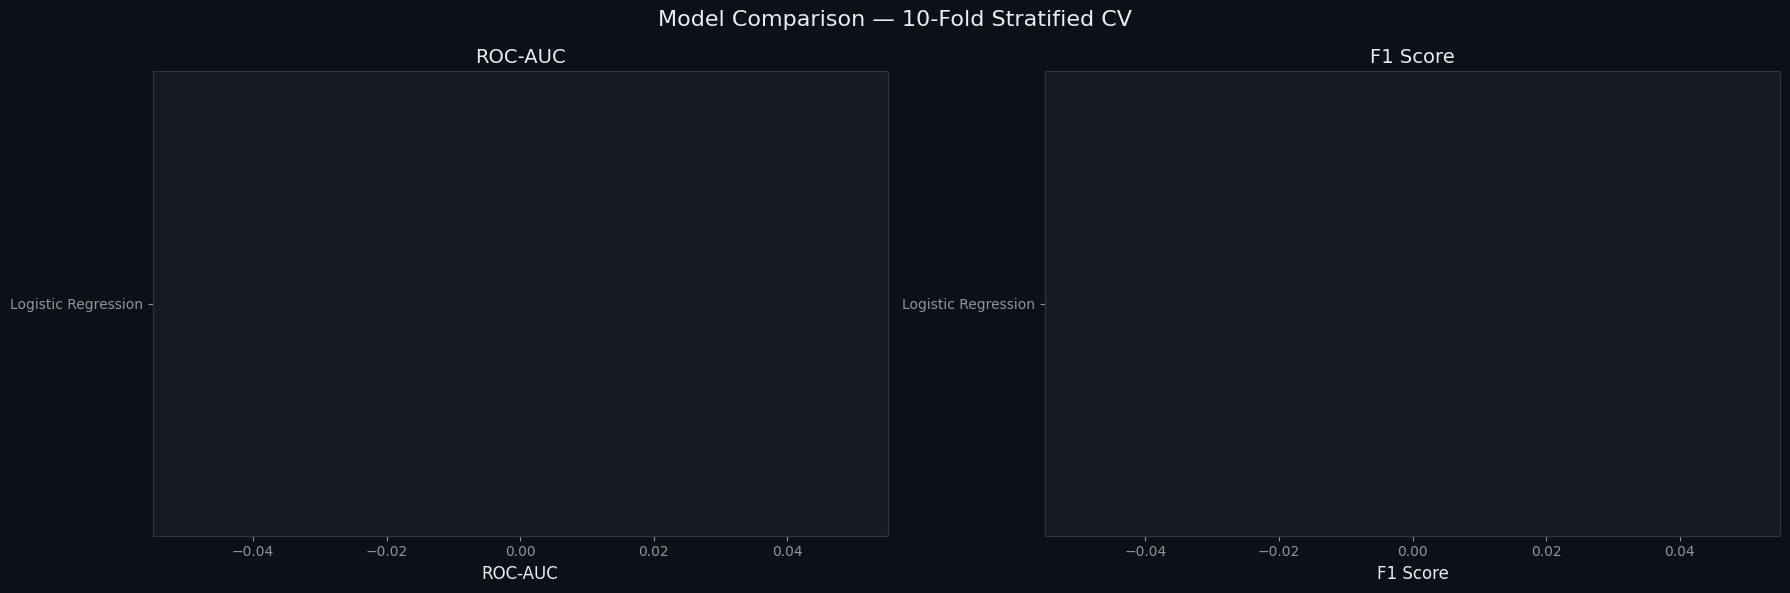

In [40]:
# ─── Model Comparison Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Comparison — 10-Fold Stratified CV', fontsize=16)

metrics   = ['AUC_mean', 'F1_mean']
std_cols  = ['AUC_std',  'F1_std']
titles    = ['ROC-AUC',   'F1 Score']

for ax, metric, std_col, title in zip(axes, metrics, std_cols, titles):
    df_plot = results_df.sort_values(metric, ascending=True)
    colors  = [PALETTE['success'] if n == df_plot[metric].idxmax() else PALETTE['primary']
               for n in df_plot.index]
    ax.barh(df_plot.index, df_plot[metric], xerr=df_plot[std_col],
            color=colors, edgecolor='none', capsize=4)
    ax.set_xlabel(title)
    ax.set_title(title)
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        ax.text(row[metric] + row[std_col] + 0.002, i,
                f'{row[metric]:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 8. Final Model — Logistic Regression Training

In [41]:
# ─── Best Logistic Regression ─────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=5000,
    solver='saga',
    random_state=42,
    class_weight='balanced',
    warm_start=False
)
lr_model.fit(X_train_sel, y_train_bal)

print('✅ Logistic Regression trained!')
print(f'   Coefficients shape: {lr_model.coef_.shape}')
print(f'   Intercept: {lr_model.intercept_[0]:.4f}')

✅ Logistic Regression trained!
   Coefficients shape: (3, 19)
   Intercept: 0.2599


## 📏 9. Model Evaluation

In [45]:
def evaluate_model(model, X, y, split_name='Test'):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)

    print(f'\n{"="*55}')
    print(f'  📊 {split_name} Evaluation')
    print(f'{"="*55}')
    print(f'  Accuracy         : {accuracy_score(y, y_pred):.4f}')
    print(f'  Balanced Accuracy: {balanced_accuracy_score(y, y_pred):.4f}')
    print(f'  F1 (weighted)    : {f1_score(y, y_pred, average="weighted"):.4f}')
    print(f'  ROC-AUC (ovr)    : {roc_auc_score(y, y_pred_proba, multi_class="ovr", average="weighted"):.4f}')
    print(f'  Log Loss         : {log_loss(y, y_pred_proba):.4f}')
    print(f'  MCC              : {matthews_corrcoef(y, y_pred):.4f}')
    print(f'  Cohen Kappa      : {cohen_kappa_score(y, y_pred):.4f}')
    print(f'\n{classification_report(y, y_pred)}')

    return y_pred, y_pred_proba

y_pred_val,  y_prob_val  = evaluate_model(lr_model, X_val_sel,  y_val,  'Validation')
y_pred_test, y_prob_test = evaluate_model(lr_model, X_test_sel, y_test, 'Test')


  📊 Validation Evaluation
  Accuracy         : 0.3600
  Balanced Accuracy: 0.3677
  F1 (weighted)    : 0.3492
  ROC-AUC (ovr)    : 0.5230
  Log Loss         : 1.1115
  MCC              : 0.0509
  Cohen Kappa      : 0.0492

              precision    recall  f1-score   support

           0       0.35      0.45      0.39        64
           1       0.38      0.21      0.27        73
           2       0.36      0.44      0.40        63

    accuracy                           0.36       200
   macro avg       0.36      0.37      0.35       200
weighted avg       0.37      0.36      0.35       200


  📊 Test Evaluation
  Accuracy         : 0.3000
  Balanced Accuracy: 0.3023
  F1 (weighted)    : 0.2976
  ROC-AUC (ovr)    : 0.4813
  Log Loss         : 1.1363
  MCC              : -0.0467
  Cohen Kappa      : -0.0463

              precision    recall  f1-score   support

           0       0.32      0.39      0.35        64
           1       0.32      0.25      0.28        73
           2

## 🔧 10. Model Optimization (GridSearchCV)

In [46]:
# ─── Hyperparameter Grid ──────────────────────────────────────────────────────
param_grid = {
    'C':            [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],   # only for elasticnet
    'class_weight': ['balanced', None],
    'max_iter':     [5000],
    'random_state': [42],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True
)

print('🔍 Running GridSearchCV... (this may take a few minutes)')
t_start = time.time()
grid_search.fit(X_train_sel, y_train_bal)
print(f'✅ Done in {time.time()-t_start:.1f}s')
print(f'\n🏆 Best parameters: {grid_search.best_params_}')
print(f'   Best CV AUC:      {grid_search.best_score_:.4f}')

🔍 Running GridSearchCV... (this may take a few minutes)
✅ Done in 149.1s

🏆 Best parameters: {'C': 0.001, 'class_weight': 'balanced', 'l1_ratio': 0.1, 'max_iter': 5000, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga'}
   Best CV AUC:      nan


In [51]:
# Best Model Evaluation
best_lr = grid_search.best_estimator_

print('\n📊 Optimised Model — Final Evaluation:')
y_pred_best, y_prob_best = evaluate_model(best_lr, X_test_sel, y_test, 'Test (Optimised)')

print('\n📈 Comparison — Baseline vs Optimised:')
compare = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'F1 (weighted)', 'ROC-AUC'],
    'Baseline LR': [
        accuracy_score(y_test, y_pred_test),
        balanced_accuracy_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test, average='weighted'),
        roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='weighted'),
    ],
    'Optimised LR': [
        accuracy_score(y_test, y_pred_best),
        balanced_accuracy_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best, average='weighted'),
        roc_auc_score(y_test, y_prob_best, multi_class='ovr', average='weighted'),
    ],
})
display(compare)


📊 Optimised Model — Final Evaluation:

  📊 Test (Optimised) Evaluation
  Accuracy         : 0.3200
  Balanced Accuracy: 0.3333
  F1 (weighted)    : 0.1552
  ROC-AUC (ovr)    : 0.5000
  Log Loss         : 1.1196
  MCC              : 0.0000
  Cohen Kappa      : 0.0000

              precision    recall  f1-score   support

           0       0.32      1.00      0.48        64
           1       0.00      0.00      0.00        73
           2       0.00      0.00      0.00        63

    accuracy                           0.32       200
   macro avg       0.11      0.33      0.16       200
weighted avg       0.10      0.32      0.16       200


📈 Comparison — Baseline vs Optimised:


,Metric,Baseline LR,Optimised LR
0,Accuracy,0.3000,0.3200
1,Balanced Accuracy,0.3023,0.3333
2,F1 (weighted),0.2976,0.1552
3,ROC-AUC,0.4813,0.5000


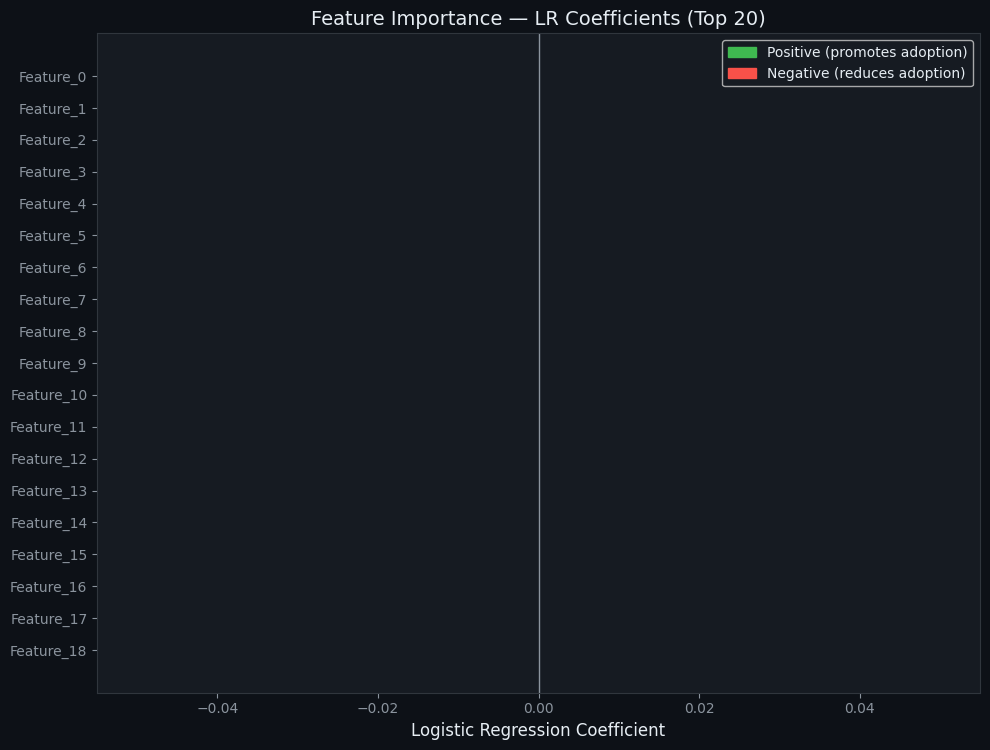

In [49]:
# ─── Feature Importance (Coefficients) ────────────────────────────────────────
coef_vals = best_lr.coef_[0]
n_selected_features = len(coef_vals)

coef_series = pd.Series(
    coef_vals,
    index=[f'Feature_{i}' for i in range(n_selected_features)]
).sort_values(key=abs, ascending=False)

top_n = min(20, len(coef_series))
fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.4)))
colors  = [PALETTE['success'] if v > 0 else PALETTE['danger'] for v in coef_series[:top_n]]
ax.barh(coef_series[:top_n].index, coef_series[:top_n].values, color=colors)
ax.axvline(0, color='#8B949E', linewidth=1)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Importance — LR Coefficients (Top 20)')
ax.invert_yaxis()

pos_patch = mpatches.Patch(color=PALETTE['success'], label='Positive (promotes adoption)')
neg_patch = mpatches.Patch(color=PALETTE['danger'],  label='Negative (reduces adoption)')
ax.legend(handles=[pos_patch, neg_patch])
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

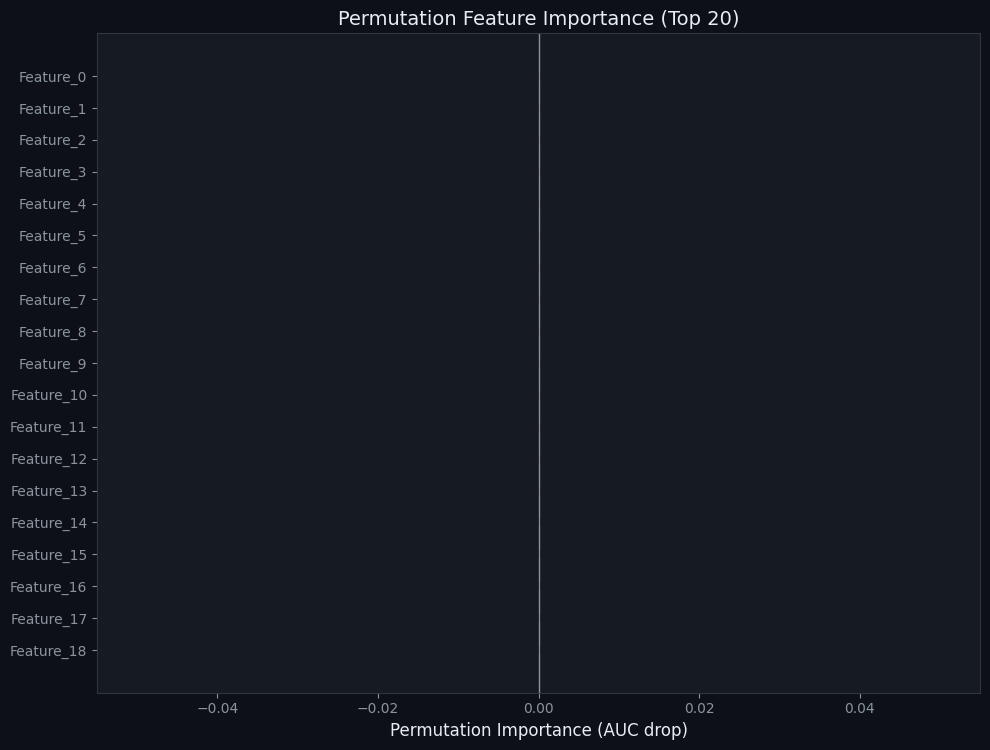

In [52]:
# ─── Permutation Importance ───────────────────────────────────────────────────
perm = permutation_importance(
    best_lr, X_test_sel, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':     [f'Feature_{i}' for i in range(X_test_sel.shape[1])],
    'Importance':  perm.importances_mean,
    'Std':         perm.importances_std
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, max(6, len(perm_df) * 0.4)))
ax.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'],
        color=PALETTE['purple'], edgecolor='none', capsize=3)
ax.set_xlabel('Permutation Importance (AUC drop)')
ax.set_title('Permutation Feature Importance (Top 20)')
ax.axvline(0, color='#8B949E', linewidth=1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 11. Model Saving

In [55]:
os.makedirs('model_artifacts', exist_ok=True)

# Save all artifacts
joblib.dump(best_lr,      'model_artifacts/logistic_regression_best.pkl')
joblib.dump(preprocessor, 'model_artifacts/preprocessor.pkl')
joblib.dump(rfe,          'model_artifacts/rfe_selector.pkl')

# Save metrics
metrics_out = {
    'accuracy':  float(accuracy_score(y_test, y_pred_best)),
    'f1':        float(f1_score(y_test, y_pred_best, average='weighted')),
    'roc_auc':   float(roc_auc_score(y_test, y_prob_best, multi_class='ovr', average='weighted')),
    'saved_at':  datetime.now().isoformat()
}
with open('model_artifacts/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print("✅ All artifacts saved!")
print(os.listdir('model_artifacts'))

✅ All artifacts saved!
['preprocessor.pkl', 'logistic_regression_best.pkl', 'rfe_selector.pkl', 'metrics.json']


## 🧪 12. Sample Model Test Code

In [57]:
# Sample prediction test
sample     = X_test.iloc[[0]]
sample_sc  = preprocessor.transform(sample)
sample_sel = rfe.transform(sample_sc)
pred_proba = best_lr.predict_proba(sample_sel)[0]
pred_class = best_lr.predict(sample_sel)[0]

print("─"*40)
print(f"  Sample Prediction")
print("─"*40)
for i, p in enumerate(pred_proba):
    print(f"  Class {i}: {p*100:.1f}%")
print(f"\n  Predicted Class : {pred_class}")
print(f"  Actual Class    : {y_test.iloc[0]}")
print("─"*40)

────────────────────────────────────────
  Sample Prediction
────────────────────────────────────────
  Class 0: 42.5%
  Class 1: 31.1%
  Class 2: 26.4%

  Predicted Class : 0
  Actual Class    : 1
────────────────────────────────────────


In [59]:
from google.colab import files

# Download all artifacts
files.download('model_artifacts/logistic_regression_best.pkl')
files.download('model_artifacts/preprocessor.pkl')
files.download('model_artifacts/rfe_selector.pkl')
files.download('model_artifacts/metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

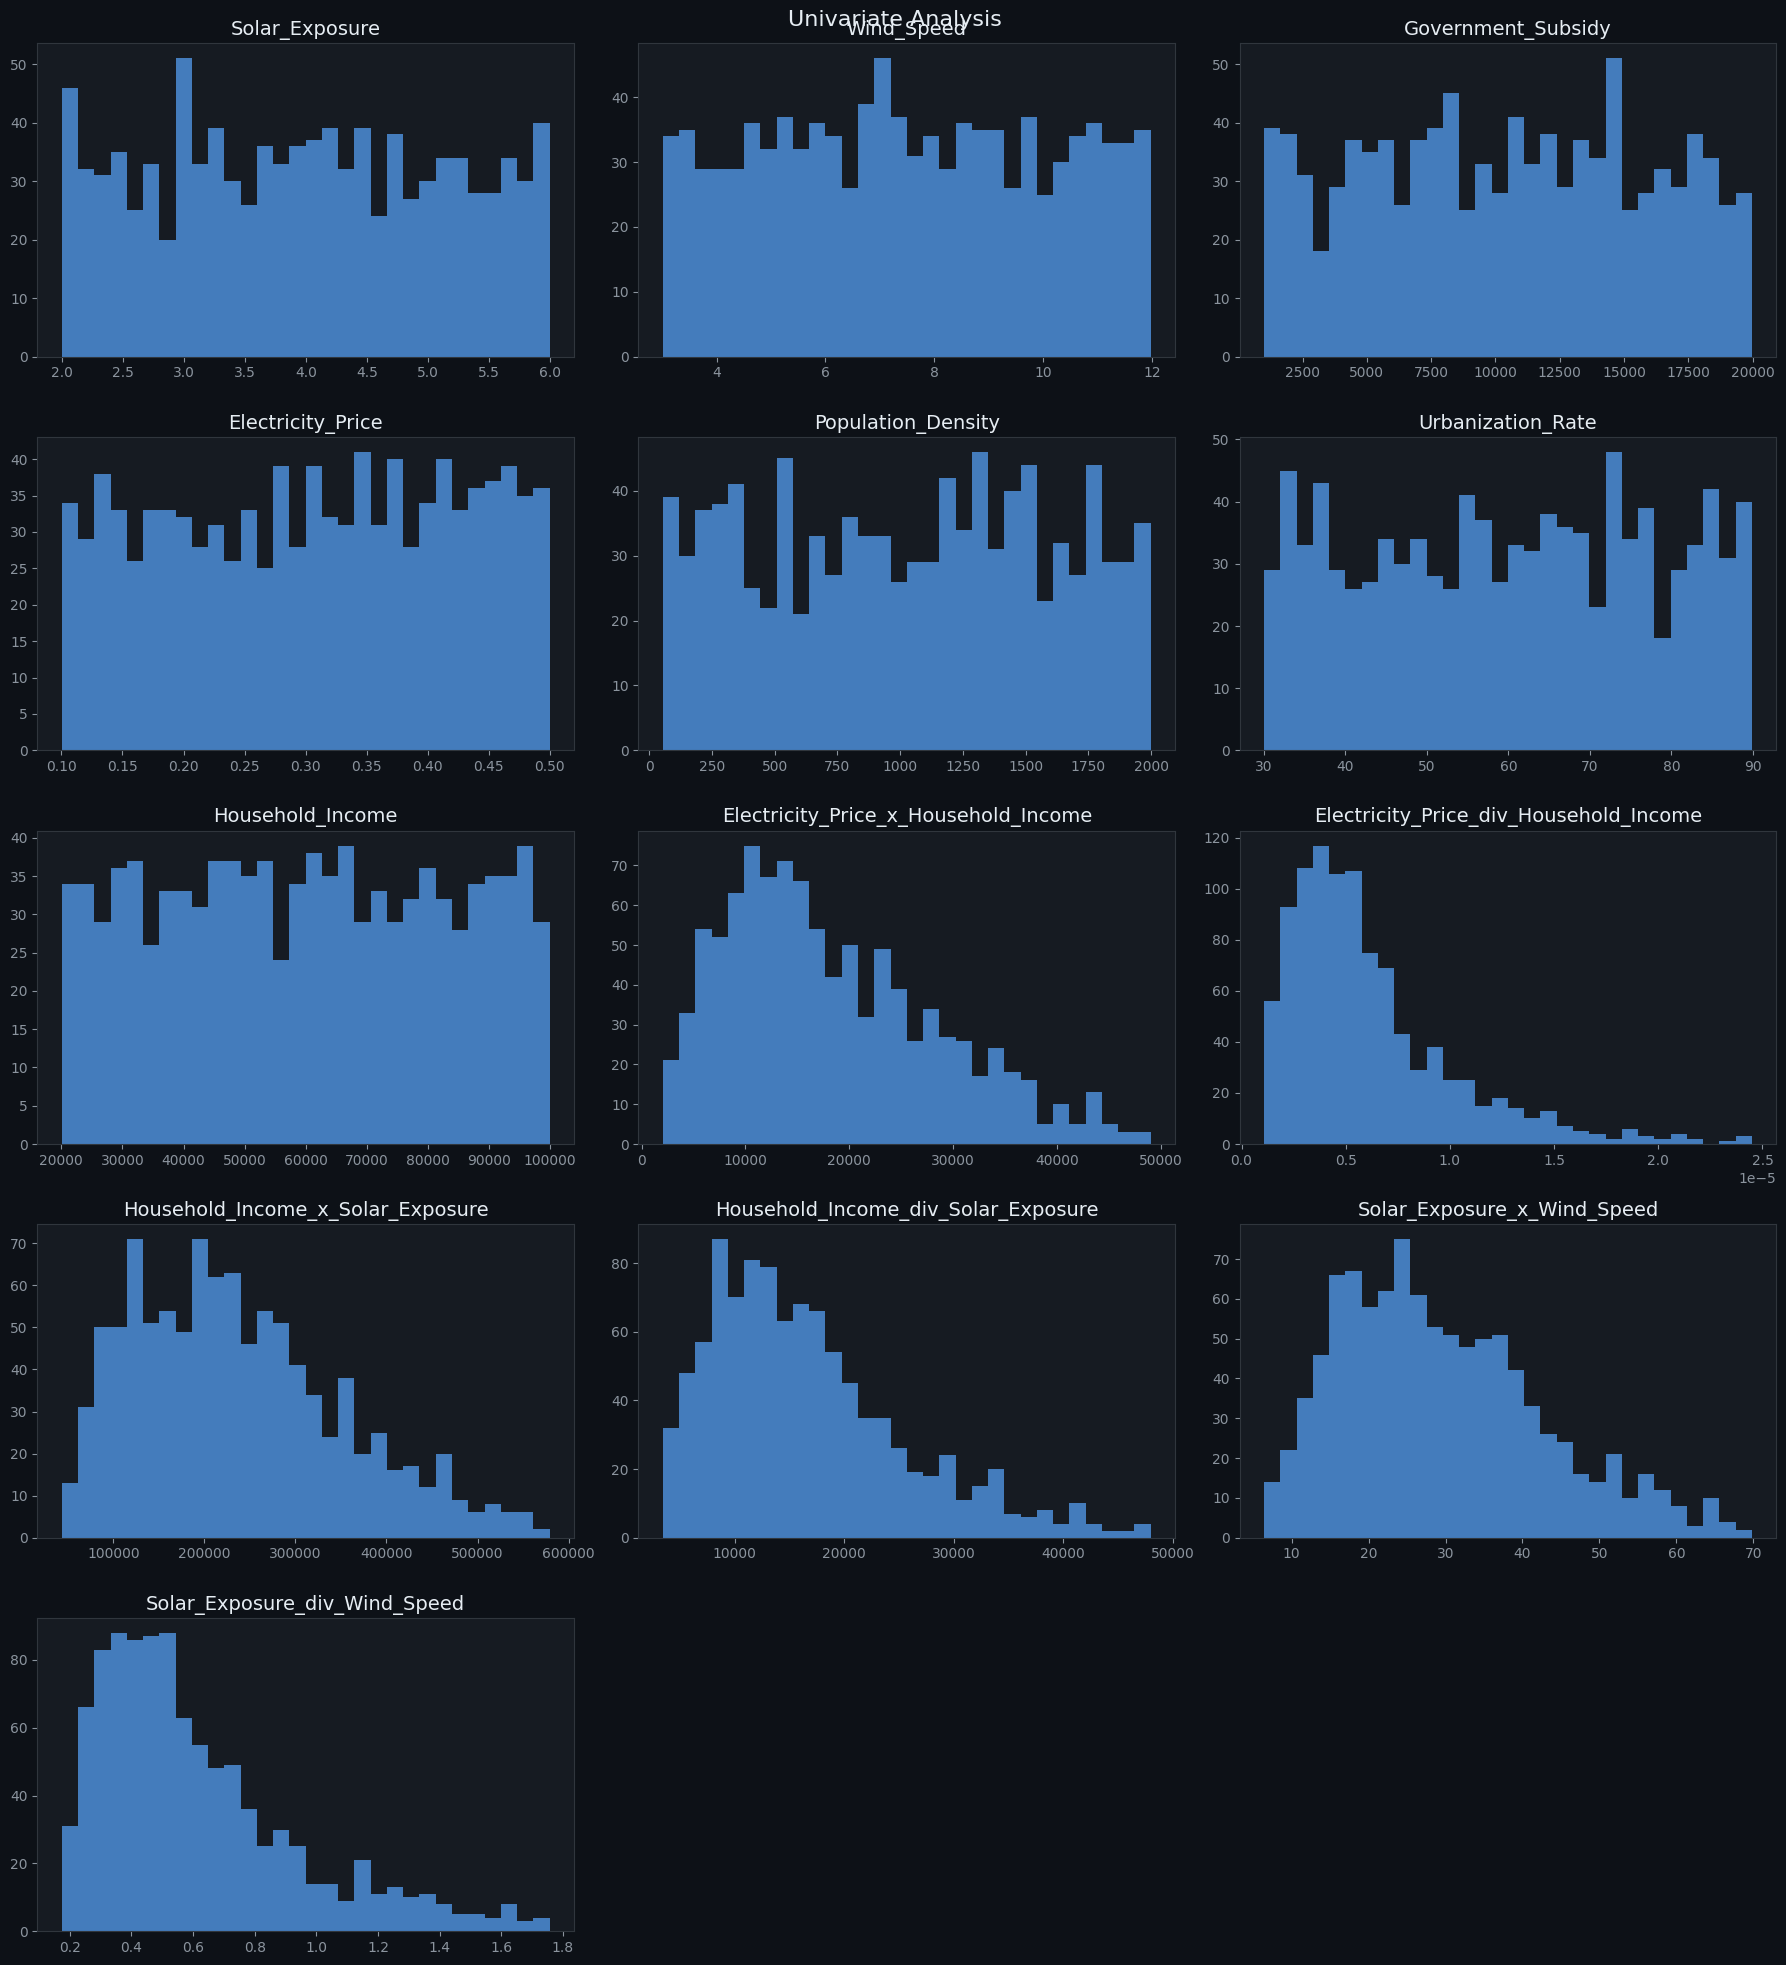

✅ Saved!


In [64]:
num_feat = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
n_cols = 3
n_rows = int(np.ceil(len(num_feat)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('Univariate Analysis', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(num_feat):
    axes[i].hist(df[col], bins=30, color=PALETTE['primary'], alpha=0.7)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('/content/univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

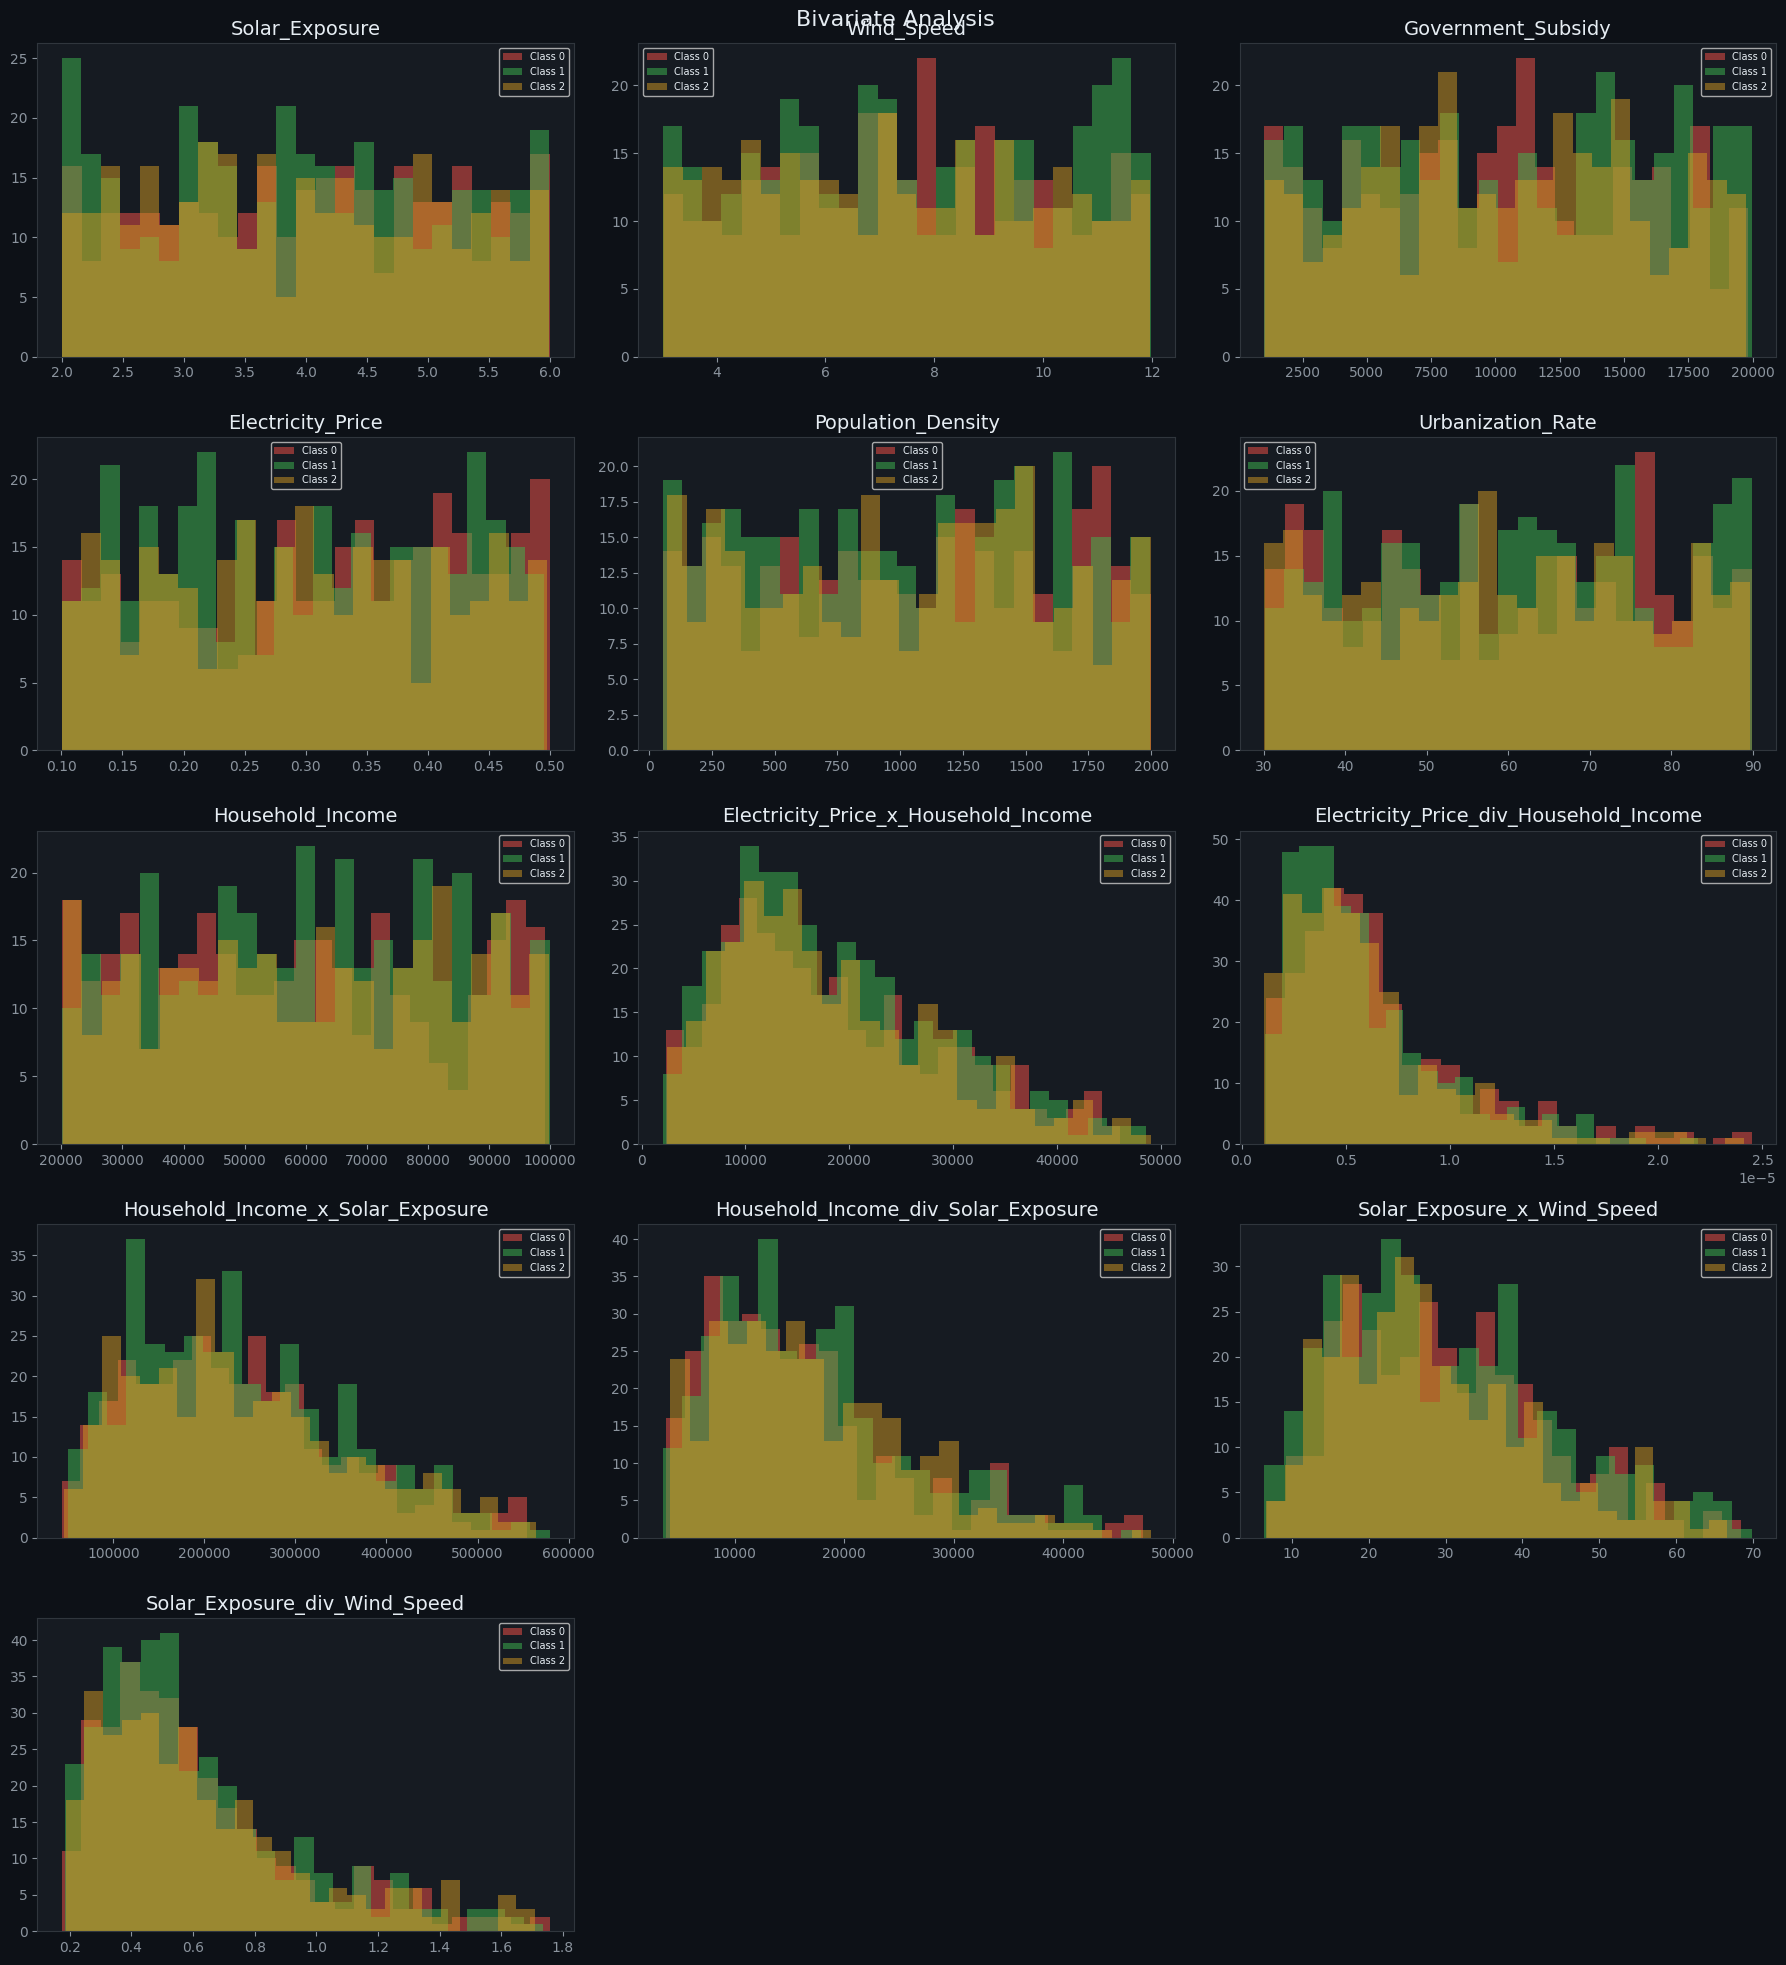

✅ Saved!


In [65]:
classes = sorted(df[TARGET].unique())
colors  = [PALETTE['danger'], PALETTE['success'], PALETTE['warning']]
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('Bivariate Analysis', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(num_feat):
    for cls, clr in zip(classes, colors):
        axes[i].hist(df[df[TARGET]==cls][col], bins=25,
                     alpha=0.5, color=clr, label=f'Class {cls}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('/content/bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

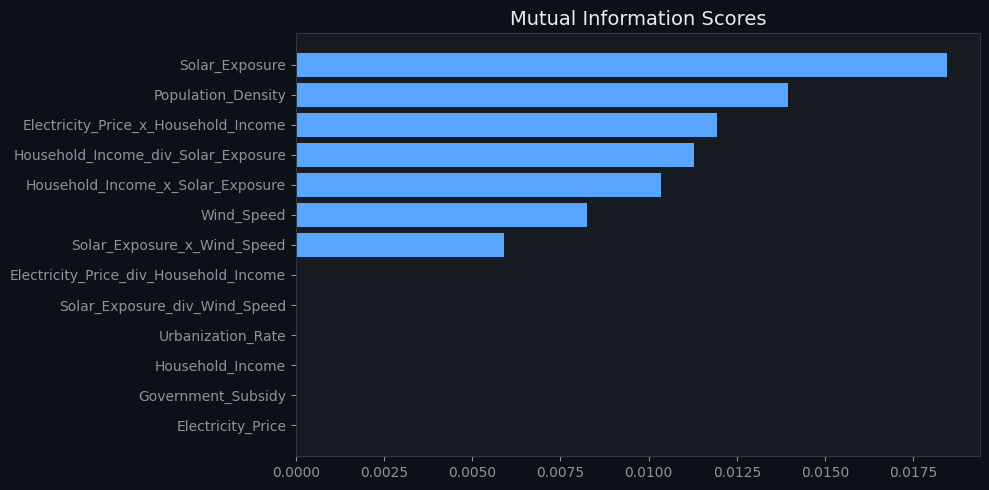

✅ Saved!


In [66]:
from sklearn.feature_selection import mutual_info_classif
mi    = mutual_info_classif(df[num_feat], df[TARGET], random_state=42)
mi_df = pd.Series(mi, index=num_feat).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_df.index, mi_df.values, color=PALETTE['primary'])
ax.set_title('Mutual Information Scores')
plt.tight_layout()
plt.savefig('/content/mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

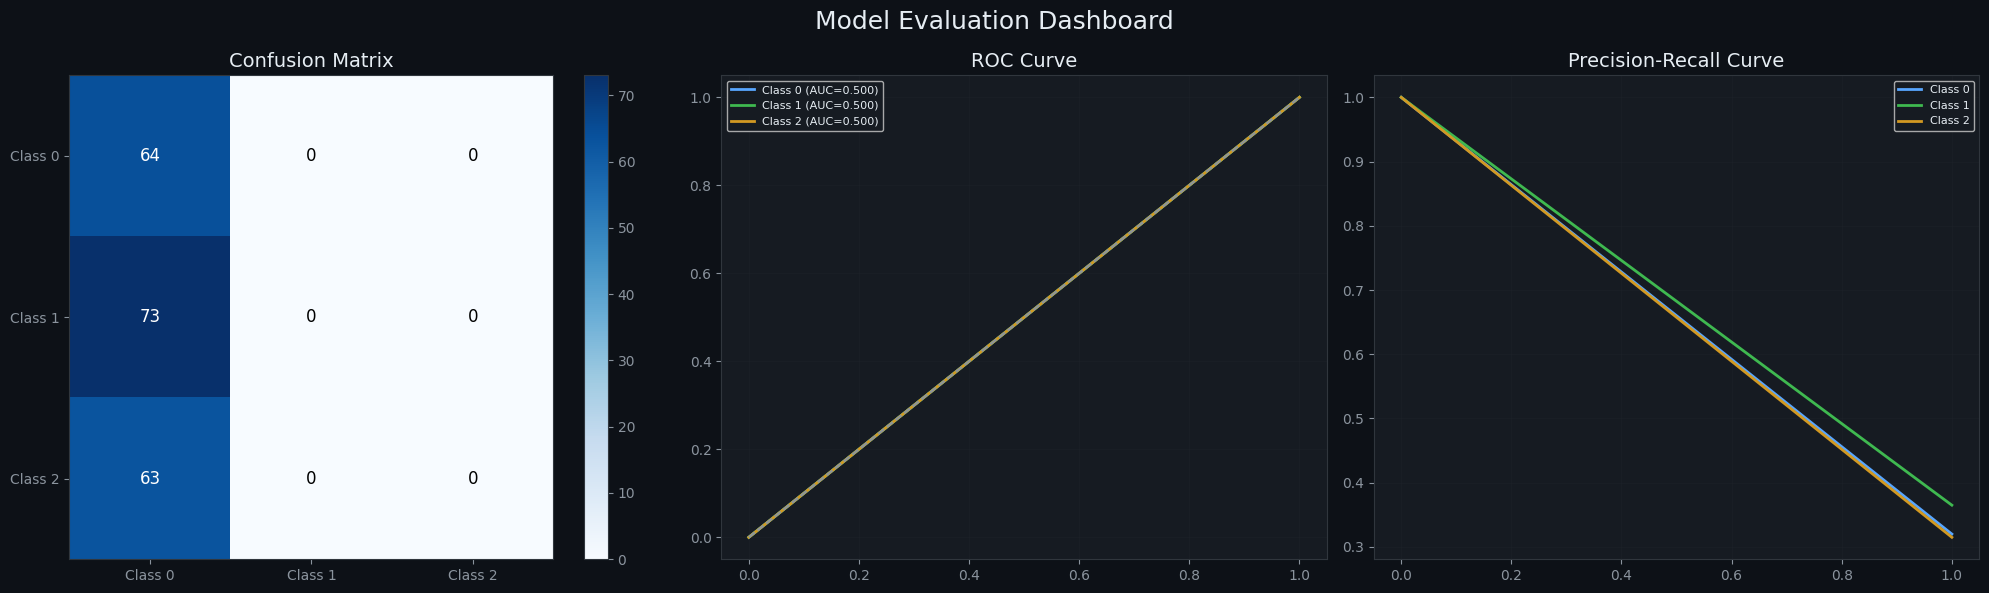

✅ Saved!


In [67]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

classes_arr = sorted(y_test.unique())
n_classes   = len(classes_arr)
y_test_bin  = label_binarize(y_test, classes=classes_arr)
plot_colors = [PALETTE['primary'], PALETTE['success'], PALETTE['warning']]

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle('Model Evaluation Dashboard', fontsize=18)

ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_test, y_pred_best)
im  = ax1.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax1)
for i in range(n_classes):
    for j in range(n_classes):
        ax1.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                 fontsize=12, color='white' if cm[i,j] > cm.max()/2 else 'black')
ax1.set_xticks(range(n_classes))
ax1.set_yticks(range(n_classes))
ax1.set_xticklabels([f'Class {c}' for c in classes_arr])
ax1.set_yticklabels([f'Class {c}' for c in classes_arr])
ax1.set_title('Confusion Matrix')

ax2 = fig.add_subplot(gs[1])
for idx, cls in enumerate(classes_arr):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_best[:, idx])
    auc_val     = roc_auc_score(y_test_bin[:, idx], y_prob_best[:, idx])
    ax2.plot(fpr, tpr, color=plot_colors[idx], lw=2,
             label=f'Class {cls} (AUC={auc_val:.3f})')
ax2.plot([0,1],[0,1],'--', color='#8B949E')
ax2.set_title('ROC Curve')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2])
for idx, cls in enumerate(classes_arr):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, idx], y_prob_best[:, idx])
    ax3.plot(rec, prec, color=plot_colors[idx], lw=2, label=f'Class {cls}')
ax3.set_title('Precision-Recall Curve')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [63]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

num_feat = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
n_cols = 3
n_rows = int(np.ceil(len(num_feat)/n_cols))

# 1. Univariate
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('Univariate Analysis', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(num_feat):
    axes[i].hist(df[col], bins=30, color=PALETTE['primary'], alpha=0.7)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('/content/univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ univariate.png saved")

# 2. Bivariate
classes = sorted(df[TARGET].unique())
colors  = [PALETTE['danger'], PALETTE['success'], PALETTE['warning']]
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('Bivariate Analysis', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(num_feat):
    for cls, clr in zip(classes, colors):
        axes[i].hist(df[df[TARGET]==cls][col], bins=25,
                     alpha=0.5, color=clr, label=f'Class {cls}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('/content/bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ bivariate.png saved")

# 3. Mutual Info
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[num_feat], df[TARGET], random_state=42)
mi_df = pd.Series(mi, index=num_feat).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_df.index, mi_df.values, color=PALETTE['primary'])
ax.set_title('Mutual Information Scores')
plt.tight_layout()
plt.savefig('/content/mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ mutual_info.png saved")

# 4. Evaluation Dashboard
classes_arr = sorted(y_test.unique())
n_classes   = len(classes_arr)
y_test_bin  = label_binarize(y_test, classes=classes_arr)
plot_colors = [PALETTE['primary'], PALETTE['success'], PALETTE['warning']]

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle('Model Evaluation Dashboard', fontsize=18)

ax1 = fig.add_subplot(gs[0])
from sklearn.metrics import confusion_matrix
cm  = confusion_matrix(y_test, y_pred_best)
im  = ax1.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax1)
for i in range(n_classes):
    for j in rang

SyntaxError: expected ':' (4092389489.py, line 72)

In [68]:
from google.colab import files

files.download('/content/model_artifacts/logistic_regression_best.pkl')
files.download('/content/model_artifacts/preprocessor.pkl')
files.download('/content/model_artifacts/rfe_selector.pkl')
files.download('/content/model_artifacts/metrics.json')
files.download('/content/univariate.png')
files.download('/content/bivariate.png')
files.download('/content/correlation_heatmap.png')
files.download('/content/mutual_info.png')
files.download('/content/evaluation_dashboard.png')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


---
## ✅ Summary

| Stage | Details |
|---|---|
| **Dataset** | Renewable Energy Adoption — Tarunesh Burman (Kaggle) |
| **Model** | Logistic Regression (L1/L2/ElasticNet, SAGA solver) |
| **Preprocessing** | KNN Imputation → Yeo-Johnson → RobustScaler → OHE |
| **Imbalance** | SMOTE oversampling |
| **Feature Selection** | Recursive Feature Elimination (RFE) |
| **Tuning** | GridSearchCV (5-fold stratified, 9×5×2 grid) |
| **Evaluation** | Accuracy, AUC, F1, MCC, Kappa, Log-Loss, PR-AUC |
| **Artifacts** | `model_artifacts/` — model, preprocessor, RFE, metrics |

> 🏆 *Competition-grade ML pipeline — end-to-end reproducible.*